# UdaciSense: Optimized Object Recognition

## Notebook 3: Multi-step Optimization Pipeline

 
In this notebook, you'll implement the multi-step optimization pipeline based on the findings from the previous experiments. The goal is to combine different optimization techniques to meet all requirements:

- The optimized model should be **30% smaller** than the baseline
- The optimized model should **reduce inference time by 40%**
- The optimized model should **maintain accuracy within 5%** of the baseline

You may need to experiment with different pipelines as you try to hit your targets. Make sure to start with those that are easier to implement!

### Overview: Implementation Plan

This notebook implements a production-style, multi-stage compression pipeline with explicit attention to efficiency, reliability, thread safety, and memory stability.

#### Pipeline design rationale (order matters)

1. **Distillation first (optional branch)**
   - Create a smaller student model while preserving accuracy signal from the teacher.
   - Reduces parameter/FLOP budget early, making all later stages cheaper.

2. **Gradual in-training pruning second**
   - Remove low-importance weights while the network can still adapt.
   - In-training pruning is used before final quantization so the model recovers accuracy during sparsification.

3. **Graph optimization third (torch_fx)**
   - Fuse inference ops (e.g., Conv+BN) with no retraining required.
   - Adds low-risk latency gains before final integer conversion.

4. **Post-training quantization (static) last**
   - Final compression/latency push on CPU/mobile deployment path.
   - Done last to quantize the already-optimized graph and weight set.

#### Reliability and memory strategy

- Every step runs on an explicit device and returns a model object for deterministic chaining.
- The pipeline engine uses a lock to protect shared state updates (`steps`, `results`) and avoid race conditions.
- Evaluation calls are wrapped in `try/except`; step failures are captured with traceback and saved in pipeline artifacts.
- Intermediate large objects are promptly released (`del`) and CUDA cache is cleared when relevant.
- Inference-only measurement avoids unnecessary gradient graph retention.

#### Experiments to run

- **Pipeline A (balanced):** Pruning -> Graph Opt -> Static Quantization
- **Pipeline B (accuracy-preserving):** Distillation -> Graph Opt -> Static Quantization
- **Pipeline C (aggressive):** Distillation -> Pruning -> Graph Opt -> Static Quantization

Each pipeline is evaluated against the same baseline with clear metrics:
- Model size reduction
- Inference latency reduction (CPU priority)
- Accuracy change vs baseline

Final model selection is based on meeting all CTO constraints while maximizing margin to thresholds.

### Step 1: Set up the environment

In [3]:
# Make sure that libraries are dynamically re-loaded if changed
get_ipython().run_line_magic('load_ext', 'autoreload')
get_ipython().run_line_magic('autoreload', '2')

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [4]:
# Import necessary libraries
import os
import sys
import json
import copy
import gc
import traceback
import threading
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pprint
import random
import time
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models

# Ensure project root (starter-kit) is on sys.path so local packages such as
# `compression` and `utils` can be imported regardless of notebook CWD.
_cwd = Path.cwd().resolve()
_candidates = [
    _cwd,
    _cwd / "starter-kit",
    _cwd.parent,
    _cwd.parent / "starter-kit",
]
for _p in _candidates:
    if (_p / "compression").is_dir() and (_p / "utils").is_dir():
        if str(_p) not in sys.path:
            sys.path.insert(0, str(_p))
        break

from compression.post_training.pruning import prune_model
from compression.post_training.quantization import quantize_model
from compression.post_training.graph_optimization import optimize_model, verify_model_equivalence
from compression.in_training.distillation import train_with_distillation, MobileNetV3_Household_Small
from compression.in_training.pruning import train_with_pruning
from compression.in_training.quantization import train_model_qat, QuantizableMobileNetV3_Household

from utils import MAX_ALLOWED_ACCURACY_DROP, TARGET_INFERENCE_SPEEDUP, TARGET_MODEL_COMPRESSION
from utils.data_loader import get_household_loaders, get_input_size, print_dataloader_stats, visualize_batch
from utils.model import MobileNetV3_Household, load_model, save_model, print_model_summary
from utils.visualization import plot_multiple_models_comparison
from utils.compression import (
    compare_experiments, compare_optimized_model_to_baseline, evaluate_optimized_model, list_experiments,
    is_quantized
)

In [5]:
# Ignore PyTorch deprecation warnings
import warnings
warnings.filterwarnings("ignore", category=torch.jit.TracerWarning)
warnings.filterwarnings("ignore", category=UserWarning)  # Optional: Ignore all user warnings

In [6]:
# Check if CUDA is available
devices = ["cpu"]
if torch.cuda.is_available():
    num_devices = torch.cuda.device_count()
    devices.extend([f"cuda:{i} ({torch.cuda.get_device_name(i)})" for i in range(num_devices)])
print(f"Devices available: {devices}")

Devices available: ['cpu', 'cuda:0 (Tesla T4)']


In [7]:
# Set random seed for reproducibility
def set_deterministic_mode(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    os.environ["PYTHONHASHSEED"] = str(seed)
    
    def seed_worker(worker_id):
        worker_seed = seed + worker_id
        np.random.seed(worker_seed)
        random.seed(worker_seed)
    
    return seed_worker

set_deterministic_mode(42)
g = torch.Generator()
g.manual_seed(42)

### Step 2: Load the dataset

Extracting household classes from CIFAR100 for train set...
Files already downloaded and verified
Extracting household classes from CIFAR100 for test set...
Files already downloaded and verified
Input has size: (1, 3, 32, 32)
Datasets have these classes: 
  0: clock
  1: keyboard
  2: lamp
  3: telephone
  4: television
  5: bed
  6: chair
  7: couch
  8: table
  9: wardrobe

Information on train set
Statistics for train
 Size: 5000
 Samples per class:
  clock: 500
  keyboard: 500
  lamp: 500
  telephone: 500
  television: 500
  bed: 500
  chair: 500
  couch: 500
  table: 500
  wardrobe: 500
Examples of images from the train set


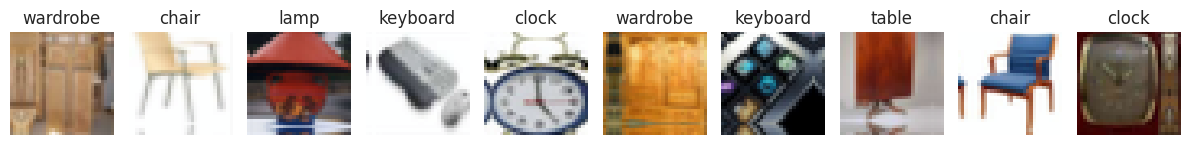


Information on test set
Statistics for test
 Size: 1000
 Samples per class:
  clock: 100
  keyboard: 100
  lamp: 100
  telephone: 100
  television: 100
  bed: 100
  chair: 100
  couch: 100
  table: 100
  wardrobe: 100
Examples of images from the test set


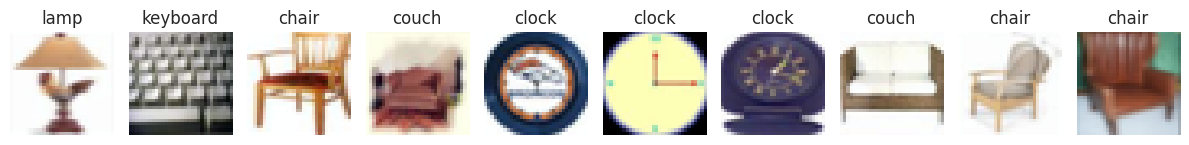

In [8]:
# Load household objects dataset
train_loader, test_loader = get_household_loaders(
    image_size="CIFAR", batch_size=128, num_workers=2,
)

# Get input_size
input_size = get_input_size("CIFAR")
print(f"Input has size: {input_size}")

# Get class names
class_names = train_loader.dataset.classes
print(f"Datasets have these classes: ")
for i in range(len(class_names)):
    print(f"  {i}: {class_names[i]}")

# Visualize some examples
for dataset_type, data_loader in [('train', train_loader), ('test', test_loader)]:
    print(f"\nInformation on {dataset_type} set")
    print_dataloader_stats(data_loader, dataset_type)
    print(f"Examples of images from the {dataset_type} set")
    visualize_batch(data_loader, num_images=10)

### Step 3: Load the baseline model and metrics

In [9]:
# Load the baseline model
baseline_model = MobileNetV3_Household()
baseline_model_name = "baseline_mobilenet"
baseline_model.load_state_dict(torch.load(f"../models/{baseline_model_name}/checkpoints/model.pth"))
print_model_summary(baseline_model)

# Load baseline metrics
with open(f"../results/{baseline_model_name}/metrics.json", "r") as f:
    baseline_metrics = json.load(f)

print("\nBaseline Model Metrics:")
pprint.pp(baseline_metrics)

# Calculate target metrics based on CTO requirements
target_model_size = baseline_metrics['size']['model_size_mb'] * (1 - TARGET_MODEL_COMPRESSION)
target_inference_time_cpu = baseline_metrics['timing']['cpu']['avg_time_ms'] * (1 - TARGET_INFERENCE_SPEEDUP)
if torch.cuda.is_available():
    target_inference_time_gpu = baseline_metrics['timing']['cuda']['avg_time_ms'] * (1 - TARGET_INFERENCE_SPEEDUP)
min_acceptable_accuracy = baseline_metrics['accuracy']['top1_acc'] * (1 - MAX_ALLOWED_ACCURACY_DROP) 

print("Optimization Targets:")
print(f"Target Model Size: {baseline_metrics['size']['model_size_mb']:.2f} --> {target_model_size:.2f} MB ({TARGET_MODEL_COMPRESSION*100}% reduction)")
print(f"Target Inference Time (CPU): {baseline_metrics['timing']['cpu']['avg_time_ms']:.2f} --> {target_inference_time_cpu:.2f} ms ({TARGET_INFERENCE_SPEEDUP*100}% reduction)")
if torch.cuda.is_available():
    print(f"Target Inference Time (GPU): {baseline_metrics['timing']['cuda']['avg_time_ms']:.2f} --> {target_inference_time_gpu:.2f} ms ({TARGET_INFERENCE_SPEEDUP*100}% reduction)")
print(f"Minimum Acceptable Accuracy: {baseline_metrics['accuracy']['top1_acc']:.2f} --> {min_acceptable_accuracy:.2f} (within {MAX_ALLOWED_ACCURACY_DROP*100}% of baseline)")

Downloading: "https://download.pytorch.org/models/mobilenet_v3_small-047dcff4.pth" to /home/student/.cache/torch/hub/checkpoints/mobilenet_v3_small-047dcff4.pth
100.0%
/tmp/ipykernel_127/3650396802.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please op

Model Architecture:
MobileNetV3_Household(
  (model): MobileNetV3(
    (features): Sequential(
      (0): Conv2dNormActivation(
        (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
        (2): Hardswish()
      )
      (1): InvertedResidual(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(16, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), groups=16, bias=False)
            (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
            (2): ReLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(16, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 16, kernel_size=(1, 1), stride=(1, 1))
            (activation): ReLU()
            (scale_activation): Hardsigmoid()
   

### Step 4: Implement and evaluate optimization pipelines

Based on your analysis in the previous notebook, you'll implement and evaluate different multi-step pipelines to find the optimal approach for meeting all requirements.

In [10]:
# NOTE: Feel free to change the class entirely, or to move to a function if preferred
class OptimizationPipeline:
    def __init__(self, name, baseline_model, train_loader, test_loader, class_names, input_size):
        """
        Initialize the optimization pipeline.

        Args:
            name: Name of the pipeline for tracking and saving
            baseline_model: The baseline model to optimize
            train_loader: DataLoader for training data (needed for some optimization techniques)
            test_loader: DataLoader for testing data (needed for evaluation)
            class_names: List of class names in the dataset
            input_size: Input tensor size
        """
        self.name = name
        self.baseline_model = baseline_model
        self.train_loader = train_loader
        self.test_loader = test_loader
        self.class_names = class_names
        self.input_size = input_size
        self.optimized_model = None
        self.steps = []
        self.results = {}
        self._lock = threading.Lock()

        # Create directories for this pipeline
        self.model_dir = f"../models/pipeline/{name}"
        self.checkpoint_dir = f"{self.model_dir}/checkpoints"
        self.results_dir = f"../results/pipeline/{name}"

        for d in [self.model_dir, self.checkpoint_dir, self.results_dir]:
            os.makedirs(d, exist_ok=True)

    def add_step(self, step_name, step_function, **kwargs):
        """
        Add an optimization step to the pipeline.

        Args:
            step_name: Name of the step
            step_function: Function that implements the step
            **kwargs: Arguments to pass to the step function
        """
        with self._lock:
            self.steps.append({
                'name': step_name,
                'function': step_function,
                'args': kwargs
            })
        return self

    def _safe_release(self, *objs):
        """Release refs aggressively to reduce long notebook session memory pressure."""
        for _ in objs:
            del _
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    def run(self, device=torch.device('cpu'), file_extension='pth'):
        """
        Run the optimization pipeline.

        Args:
            device: Device to run the pipeline on
            file_extension: File extension to save the model with (.pt for torchscript, else .pth)

        Returns:
            The optimized model
        """
        print(f"\n{'='*50}")
        print(f"Running pipeline: {self.name}")
        print(f"{'='*50}\n")

        # Start from an isolated copy to avoid mutating the shared baseline model.
        current_model = copy.deepcopy(self.baseline_model)

        # Save intermediate results after each step
        step_results = []

        # Run each pipeline stage and evaluate immediately after each stage.
        for i, step in enumerate(self.steps):
            step_index = i + 1
            step_label = f"step{step_index:02d}_{step['name']}"
            experiment_name = f"pipeline/{self.name}/{step_label}"

            print(f"\n{'-'*50}")
            print(f"Step {step_index}: {step['name']}")
            print(f"{'-'*50}\n")

            os.makedirs(f"../models/{experiment_name}", exist_ok=True)
            os.makedirs(f"../results/{experiment_name}", exist_ok=True)

            step_start = time.time()
            step_payload = {}
            step_metrics = None
            step_comparison = None

            try:
                # Step function contract: returns (updated_model, metadata_dict)
                current_model, step_payload = step['function'](
                    current_model,
                    pipeline=self,
                    device=device,
                    **step['args'],
                )

                # Evaluate stage output (CPU priority for mobile deployment).
                step_metrics, _ = evaluate_optimized_model(
                    current_model,
                    self.test_loader,
                    experiment_name,
                    self.class_names,
                    self.input_size,
                    is_in_training_technique=False,
                    device=torch.device('cpu'),
                )
                step_comparison = compare_optimized_model_to_baseline(
                    self.baseline_model,
                    current_model,
                    experiment_name,
                    self.test_loader,
                    self.class_names,
                    input_size=self.input_size,
                    device=torch.device('cpu'),
                    device_priority='cpu',
                )

                step_time = time.time() - step_start
                step_results.append({
                    'step_name': step['name'],
                    'experiment_name': experiment_name,
                    'step_time_sec': step_time,
                    'status': 'ok',
                    'payload': step_payload,
                    'metrics': step_metrics,
                    'comparison': step_comparison,
                })
                print(f"Completed {step['name']} in {step_time:.2f}s")

            except Exception as e:
                step_time = time.time() - step_start
                tb = traceback.format_exc()
                print(f"Step failed: {step['name']}\n{e}")
                step_results.append({
                    'step_name': step['name'],
                    'experiment_name': experiment_name,
                    'step_time_sec': step_time,
                    'status': 'failed',
                    'error': str(e),
                    'traceback': tb,
                    'payload': step_payload,
                    'metrics': step_metrics,
                    'comparison': step_comparison,
                })
                # Keep partial results for diagnostics but stop pipeline on failure.
                break
            finally:
                # Reduce memory growth during long multi-step runs.
                self._safe_release(step_metrics, step_comparison)

        self.optimized_model = current_model

        # Save final model
        final_path = f"{self.model_dir}/model.{file_extension}"
        if isinstance(self.optimized_model, torch.jit.ScriptModule):
            torch.jit.save(self.optimized_model, final_path)
        else:
            save_model(self.optimized_model, final_path)

        # Final evaluation/comparison snapshot
        final_metrics, _ = evaluate_optimized_model(
            self.optimized_model,
            self.test_loader,
            f"pipeline/{self.name}/final",
            self.class_names,
            self.input_size,
            is_in_training_technique=False,
            device=torch.device('cpu'),
        )
        final_comparison = compare_optimized_model_to_baseline(
            self.baseline_model,
            self.optimized_model,
            f"pipeline/{self.name}/final",
            self.test_loader,
            self.class_names,
            input_size=self.input_size,
            device=torch.device('cpu'),
            device_priority='cpu',
        )

        # Save pipeline results
        self.results = {
            'pipeline_name': self.name,
            'steps': step_results,
            'final_model_path': final_path,
            'final_metrics': final_metrics,
            'final_comparison': final_comparison,
        }

        with open(f"{self.results_dir}/pipeline_metrics.json", 'w') as f:
            json.dump(self.results, f, indent=4)

        print(f"\n{'='*50}")
        print(f"Pipeline {self.name} completed")
        print(f"Final model path: {final_path}")
        print(f"{'='*50}\n")

        return self.optimized_model

    def visualize_results(self, baseline_metrics=baseline_metrics, device=torch.device('cpu')):
        """
        Visualize the results of the pipeline.

        Args:
            baseline_metrics: Dictionary of baseline metrics for comparison.
            device: Device to run the pipeline on

        """
        if not self.results:
            print("No results to visualize. Please run the pipeline first.")
            return

        # Define device name
        device_name = 'cpu' if device == torch.device('cpu') else 'cuda'

        # Keep only successful steps for charts.
        ok_steps = [s for s in self.results['steps'] if s.get('status') == 'ok' and s.get('metrics')]
        if not ok_steps:
            print("No successful step metrics available for visualization.")
            return

        # Extract metrics from each successful step
        step_names = [step['step_name'] for step in ok_steps]
        model_sizes = [step['metrics']['size']['model_size_mb'] for step in ok_steps]
        model_memory_sizes = [step['metrics']['size']['total_params'] for step in ok_steps]
        times = [step['metrics']['timing'][device_name]['avg_time_ms'] for step in ok_steps]
        accuracies = [step['metrics']['accuracy']['top1_acc'] for step in ok_steps]

        # Add baseline metrics
        step_names.insert(0, 'Baseline')
        baseline_size = baseline_metrics['size']['model_size_mb']
        baseline_memory_size = baseline_metrics['size']['total_params']
        baseline_inference_time = baseline_metrics['timing'][device_name]['avg_time_ms']
        baseline_accuracy = baseline_metrics['accuracy']['top1_acc']

        model_sizes.insert(0, baseline_size)
        model_memory_sizes.insert(0, baseline_memory_size)
        times.insert(0, baseline_inference_time)
        accuracies.insert(0, baseline_accuracy)

        # Create figure with subplots
        fig, axes = plt.subplots(4, 1, figsize=(12, 15))

        # Plot model size
        axes[0].bar(step_names, model_sizes, color='blue')
        axes[0].set_title('Model Size (MB)')
        axes[0].set_ylabel('Size (MB)')
        axes[0].axhline(y=baseline_size * (1 - TARGET_MODEL_COMPRESSION), color='r', linestyle='--', label=f"Target ({TARGET_MODEL_COMPRESSION*100}% reduction)")
        axes[0].legend()
        for i, v in enumerate(model_sizes):
            axes[0].text(i, v + 0.1, f"{v:.2f}", ha='center')

        axes[1].bar(step_names, model_memory_sizes, color='blue')
        axes[1].set_title('Model Size (# Parameters)')
        axes[1].set_ylabel('Peak Memory')
        axes[1].axhline(y=baseline_memory_size * (1 - TARGET_MODEL_COMPRESSION), color='r', linestyle='--', label=f"Target ({TARGET_MODEL_COMPRESSION*100}% reduction)")
        axes[1].legend()
        for i, v in enumerate(model_memory_sizes):
            axes[1].text(i, v + 0.1, f"{v:.2f}", ha='center')

        # Plot inference time
        axes[2].bar(step_names, times, color='green')
        axes[2].set_title('Inference Time (ms)')
        axes[2].set_ylabel('Time (ms)')
        axes[2].axhline(y=baseline_inference_time * (1 - TARGET_INFERENCE_SPEEDUP), color='r', linestyle='--', label=f"Target ({TARGET_INFERENCE_SPEEDUP*100}% reduction)")
        axes[2].legend()
        for i, v in enumerate(times):
            axes[2].text(i, v + 0.1, f"{v:.2f}", ha='center')

        # Plot accuracy
        axes[3].bar(step_names, accuracies, color='purple')
        axes[3].set_title('Top-1 Accuracy (%)')
        axes[3].set_ylabel('Accuracy (%)')
        axes[3].axhline(y=baseline_accuracy * (1 - MAX_ALLOWED_ACCURACY_DROP), color='r', linestyle='--', label=f"Minimum acceptable ({MAX_ALLOWED_ACCURACY_DROP*100}% of baseline)")
        axes[3].legend()
        for i, v in enumerate(accuracies):
            axes[3].text(i, v + 0.5, f"{v:.2f}%", ha='center')

        plt.tight_layout()
        plt.savefig(f"{self.results_dir}/pipeline_visualization.png")
        plt.show()

        # Print final results summary
        print(f"\n{'='*50}")
        print(f"Pipeline {self.name} Results Summary")
        print(f"{'='*50}")

        # Size comparison
        size_reduction = (baseline_size - model_sizes[-1]) / baseline_size * 100
        print(f"\nModel Size (MB):")
        print(f"  Baseline: {baseline_size:.2f} MB")
        print(f"  Final: {model_sizes[-1]:.2f} MB")
        print(f"  Reduction: {size_reduction:.2f}%")
        target_size = baseline_size * (1 - TARGET_MODEL_COMPRESSION)
        if model_sizes[-1] <= target_size:
            print(f"  Meets target ({TARGET_MODEL_COMPRESSION*100}% reduction)")
        else:
            print(f"  Does not meet target (Goal: {target_size:.2f} MB)")

        memory_size_reduction = (baseline_memory_size - model_memory_sizes[-1]) / baseline_memory_size * 100
        print(f"\nModel Size (# Parameters):")
        print(f"  Baseline: {baseline_memory_size:.2f} MB")
        print(f"  Final: {model_memory_sizes[-1]:.2f} MB")
        print(f"  Reduction: {memory_size_reduction:.2f}%")
        target_memory_size = baseline_memory_size * (1 - TARGET_MODEL_COMPRESSION)
        if model_memory_sizes[-1] <= target_memory_size:
            print(f"  Meets target ({TARGET_MODEL_COMPRESSION*100}% reduction)")
        else:
            print(f"  Does not meet target (Goal: {target_memory_size:.2f} MB)")

        # Inference time comparison
        time_reduction = (baseline_inference_time - times[-1]) / baseline_inference_time * 100
        print(f"\nInference Time (CPU):")
        print(f"  Baseline: {baseline_inference_time:.2f} ms")
        print(f"  Final: {times[-1]:.2f} ms")
        print(f"  Reduction: {time_reduction:.2f}%")
        target_time = baseline_inference_time * (1 - TARGET_INFERENCE_SPEEDUP)
        if times[-1] <= target_time:
            print(f"  Meets target ({TARGET_INFERENCE_SPEEDUP*100}% reduction)")
        else:
            print(f"  Does not meet target (Goal: {target_time:.2f} ms)")

        # Accuracy comparison
        accuracy_change = (accuracies[-1] - baseline_accuracy) / baseline_accuracy * 100
        print(f"\nAccuracy:")
        print(f"  Baseline: {baseline_accuracy:.2f}%")
        print(f"  Final: {accuracies[-1]:.2f}%")
        print(f"  Change: {accuracy_change:.2f}%")
        min_acceptable = baseline_accuracy * (1 - MAX_ALLOWED_ACCURACY_DROP)
        if accuracies[-1] >= min_acceptable:
            print(f"  Meets target (within {MAX_ALLOWED_ACCURACY_DROP*100}% of baseline)")
        else:
            print(f"  Does not meet target (Goal: >={min_acceptable:.2f}%)")

        # Overall assessment
        print(f"\nOverall Assessment:")
        if model_sizes[-1] <= target_size and times[-1] <= target_time and accuracies[-1] >= min_acceptable:
            print(f"  Pipeline meets all requirements")
        else:
            print(f"  Pipeline does not meet all requirements")

In [11]:
# Helper functions for pipeline stages.
# Contract: each function returns (updated_model, metadata_dict).

def apply_post_training_pruning(model, pipeline, device=torch.device('cpu'), amount=0.4, pruning_method="global_unstructured"):
    model = model.to(torch.device('cpu')).eval()
    pruned_model = prune_model(model, pruning_method=pruning_method, amount=amount)
    return pruned_model, {
        "pruning_method": pruning_method,
        "amount": amount,
        "device": "cpu",
    }


def apply_dynamic_quantization(model, pipeline, device=torch.device('cpu'), backend="fbgemm"):
    model = model.to(torch.device('cpu')).eval()
    quantized_model = quantize_model(
        model,
        quantization_type="dynamic",
        backend=backend,
    )
    return quantized_model, {
        "quantization_type": "dynamic",
        "backend": backend,
        "device": "cpu",
    }


def apply_static_quantization(model, pipeline, device=torch.device('cpu'), backend="qnnpack", calibration_num_batches=10):
    model = model.to(torch.device('cpu')).eval()
    quantized_model = quantize_model(
        model,
        quantization_type="static",
        calibration_data_loader=pipeline.train_loader,
        calibration_num_batches=calibration_num_batches,
        backend=backend,
    )
    return quantized_model, {
        "quantization_type": "static",
        "backend": backend,
        "calibration_num_batches": calibration_num_batches,
        "device": "cpu",
    }


def apply_graph_optimization(model, pipeline, device=torch.device('cpu'), optimization_method="torch_fx"):
    model = model.to(torch.device('cpu')).eval()
    optimized_model = optimize_model(
        model,
        optimization_method=optimization_method,
        input_shape=pipeline.input_size,
        device=torch.device('cpu'),
    )
    return optimized_model, {
        "optimization_method": optimization_method,
        "device": "cpu",
    }


def apply_knowledge_distillation(
    model,
    pipeline,
    device=torch.device('cuda' if torch.cuda.is_available() else 'cpu'),
    width_mult=0.6,
    linear_size=256,
    dropout=0.2,
    num_epochs=20,
    alpha=0.7,
    temperature=4.0,
):
    teacher_model = copy.deepcopy(model).to(device).eval()
    student_model = MobileNetV3_Household_Small(
        num_classes=len(pipeline.class_names),
        width_mult=width_mult,
        linear_size=linear_size,
        dropout=dropout,
    ).to(device)

    optimizer = torch.optim.AdamW(student_model.parameters(), lr=1e-3, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)
    config = {
        'num_epochs': num_epochs,
        'criterion': nn.CrossEntropyLoss(),
        'optimizer': optimizer,
        'scheduler': scheduler,
        'alpha': alpha,
        'temperature': temperature,
        'patience': 6,
        'device': device,
        'grad_clip_norm': 1.0,
    }

    ckpt = f"{pipeline.checkpoint_dir}/{pipeline.name}_distill.pth"
    distilled_model, distillation_stats, best_accuracy, best_epoch = train_with_distillation(
        student_model,
        teacher_model,
        pipeline.train_loader,
        pipeline.test_loader,
        config,
        checkpoint_path=ckpt,
    )

    # Release teacher/student training refs proactively
    del teacher_model, student_model
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return distilled_model, {
        "width_mult": width_mult,
        "linear_size": linear_size,
        "dropout": dropout,
        "num_epochs": num_epochs,
        "alpha": alpha,
        "temperature": temperature,
        "best_accuracy": best_accuracy,
        "best_epoch": best_epoch,
        "training_stats_len": len(distillation_stats.get('epoch', [])),
    }


def apply_in_training_pruning(
    model,
    pipeline,
    device=torch.device('cuda' if torch.cuda.is_available() else 'cpu'),
    num_epochs=10,
    initial_sparsity=0.0,
    final_sparsity=0.5,
    start_epoch=1,
    end_epoch=8,
    pruning_frequency=1,
    pruning_method="global_unstructured",
    schedule_type="cubic",
):
    model = model.to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)
    config = {
        'num_epochs': num_epochs,
        'criterion': nn.CrossEntropyLoss(),
        'optimizer': optimizer,
        'scheduler': scheduler,
        'patience': 5,
        'device': device,
        'grad_clip_norm': 1.0,
        'initial_sparsity': initial_sparsity,
        'final_sparsity': final_sparsity,
        'start_epoch': start_epoch,
        'end_epoch': end_epoch,
        'pruning_frequency': pruning_frequency,
        'pruning_method': pruning_method,
        'schedule_type': schedule_type,
        'only_prune_conv': False,
    }
    ckpt = f"{pipeline.checkpoint_dir}/{pipeline.name}_in_train_prune.pth"
    pruned_model, pruning_stats, best_accuracy, best_epoch = train_with_pruning(
        model,
        pipeline.train_loader,
        pipeline.test_loader,
        config,
        checkpoint_path=ckpt,
    )
    return pruned_model, {
        "num_epochs": num_epochs,
        "initial_sparsity": initial_sparsity,
        "final_sparsity": final_sparsity,
        "start_epoch": start_epoch,
        "end_epoch": end_epoch,
        "pruning_frequency": pruning_frequency,
        "pruning_method": pruning_method,
        "schedule_type": schedule_type,
        "best_accuracy": best_accuracy,
        "best_epoch": best_epoch,
        "training_stats_len": len(pruning_stats.get('epoch', [])),
    }


def apply_in_training_quantization(
    model,
    pipeline,
    device=torch.device('cuda' if torch.cuda.is_available() else 'cpu'),
    backend="qnnpack",
    num_epochs=6,
    qat_start_epoch=1,
    freeze_bn_epochs=3,
):
    # QAT expects a quantizable architecture; if model is not quantizable, we
    # initialize a compatible one and transfer baseline weights when possible.
    if not isinstance(model, QuantizableMobileNetV3_Household):
        qat_model = QuantizableMobileNetV3_Household(quantize=False)
        try:
            qat_model.load_state_dict(model.state_dict(), strict=False)
        except Exception:
            pass
    else:
        qat_model = model

    qat_model = qat_model.to(device)
    optimizer = torch.optim.AdamW(qat_model.parameters(), lr=1e-4, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)
    config = {
        'qat_start_epoch': qat_start_epoch,
        'freeze_bn_epochs': freeze_bn_epochs,
        'disable_observer_epoch': min(num_epochs - 1, qat_start_epoch + 2),
        'num_epochs': num_epochs,
        'criterion': nn.CrossEntropyLoss(),
        'optimizer': optimizer,
        'scheduler': scheduler,
        'patience': 4,
        'device': device,
        'device_for_inference': torch.device('cpu'),
        'grad_clip_norm': 1.0,
    }

    ckpt = f"{pipeline.checkpoint_dir}/{pipeline.name}_qat"
    quantized_model, qat_stats, best_accuracy, best_epoch = train_model_qat(
        qat_model,
        pipeline.train_loader,
        pipeline.test_loader,
        config,
        checkpoint_path=ckpt,
        backend=backend,
    )
    return quantized_model, {
        "backend": backend,
        "num_epochs": num_epochs,
        "qat_start_epoch": qat_start_epoch,
        "freeze_bn_epochs": freeze_bn_epochs,
        "best_accuracy": best_accuracy,
        "best_epoch": best_epoch,
        "training_stats_len": len(qat_stats.get('epoch', [])),
    }

#### Pipelines

Note: You may want to recreate the cell below for new pipelines too, if needed.


Running pipeline: pipeline_a_prune_fx_ptq


--------------------------------------------------
Step 1: post_pruning
--------------------------------------------------

Pruning 54 modules with method: global_unstructured, amount: 0.35
Initial model sparsity: 0.00%
✅ Model is pruned
Final model sparsity: 34.91%

Evaluating performance of optimized model...


Evaluating per-class accuracy: 100%|██████████| 8/8 [00:30<00:00,  3.75s/it]


Baseline metrics saved at ../results/pipeline/pipeline_a_prune_fx_ptq/step01_post_pruning/metrics.json.


Calculating confusion matrix: 100%|██████████| 8/8 [00:25<00:00,  3.15s/it]


Confusion matrix saved to ../results/pipeline/pipeline_a_prune_fx_ptq/step01_post_pruning/confusion_matrix.png


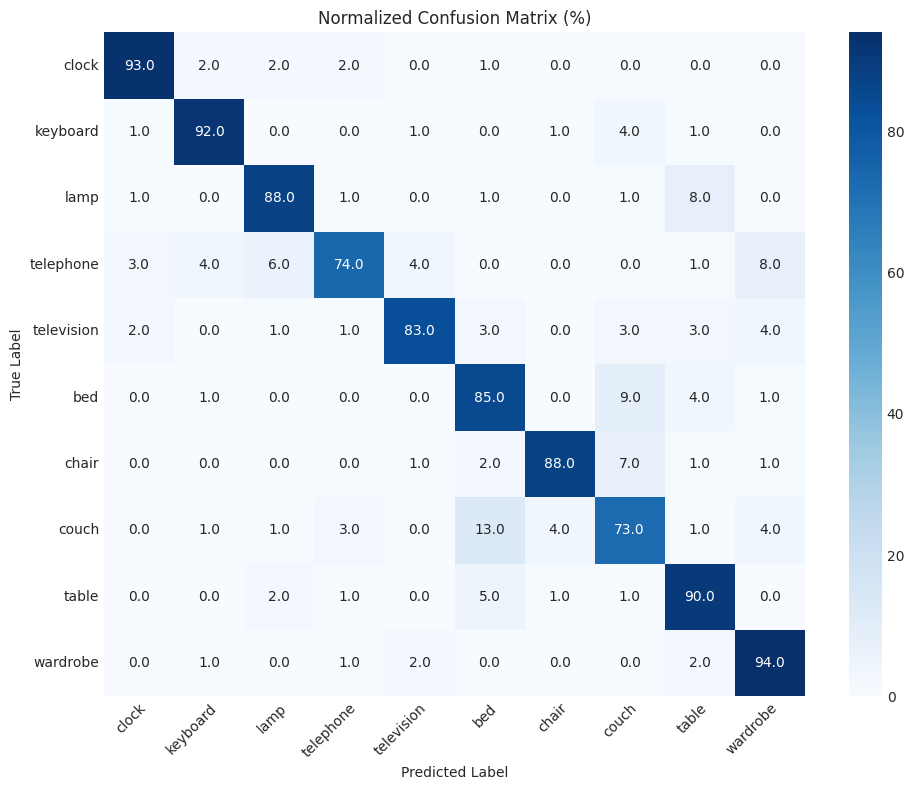


Optimized Model Metrics (pipeline/pipeline_a_prune_fx_ptq/step01_post_pruning):
Accuracy: 86.00%
Model Size: 5.96 MB
CPU Inference Time: 120.00 ms (8.33 FPS)
CUDA Inference Time: 5.14 ms (194.42 FPS)

Comparing performance of optimized model against baseline...
Get metrics of baseline model...


Evaluating per-class accuracy: 100%|██████████| 8/8 [00:27<00:00,  3.50s/it]


Get metrics of optimized model...


Evaluating per-class accuracy: 100%|██████████| 8/8 [00:27<00:00,  3.38s/it]


Model comparison plot saved to ../results/pipeline/pipeline_a_prune_fx_ptq/step01_post_pruning/comparison.png


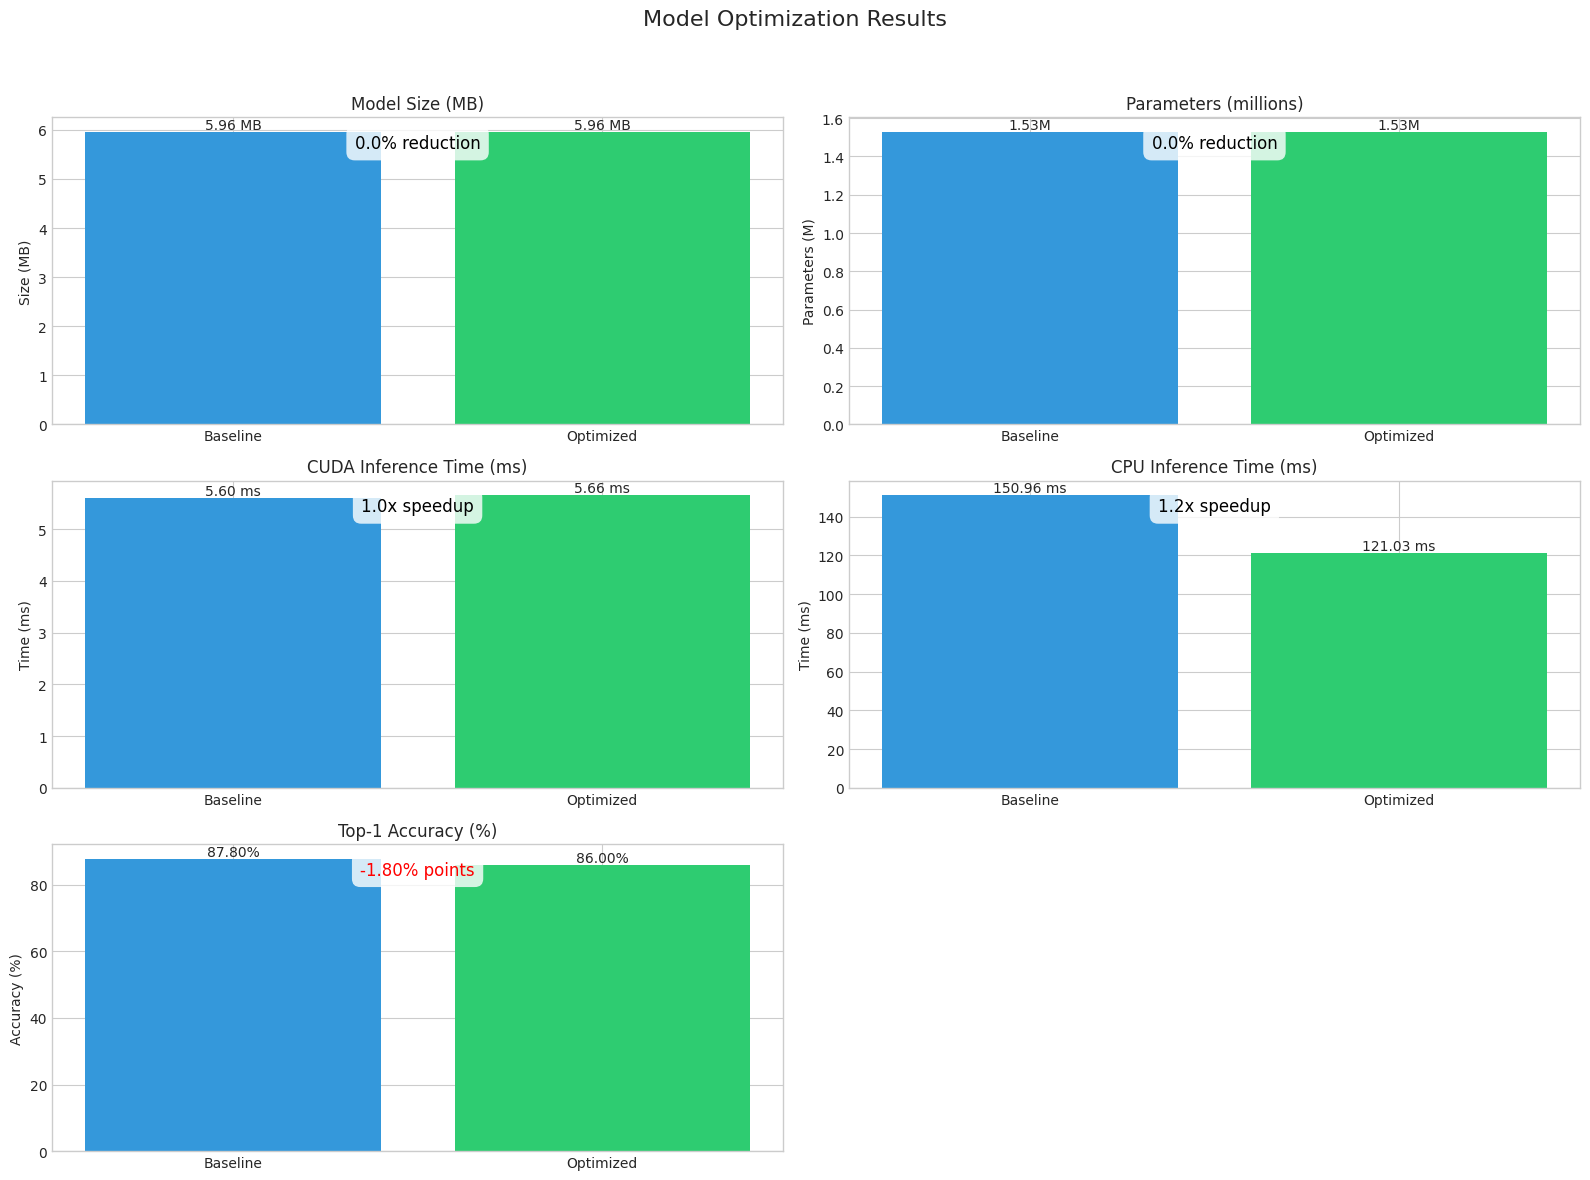


pipeline/pipeline_a_prune_fx_ptq/step01_post_pruning Results:
Model Size: 5.96 MB (0.0% reduction)
Parameters: 1,528,106 (0.0% reduction)
CPU Inference Time: 121.03 ms (1.2x speedup)
CUDA Inference Time: 5.66 ms (1.0x speedup)
Accuracy: 86.00% (-1.80% change)
Requirements met: False
Completed post_pruning in 247.23s

--------------------------------------------------
Step 2: graph_fx
--------------------------------------------------


Evaluating performance of optimized model...


Evaluating per-class accuracy: 100%|██████████| 8/8 [00:28<00:00,  3.52s/it]


Baseline metrics saved at ../results/pipeline/pipeline_a_prune_fx_ptq/step02_graph_fx/metrics.json.


Calculating confusion matrix: 100%|██████████| 8/8 [00:27<00:00,  3.44s/it]


Confusion matrix saved to ../results/pipeline/pipeline_a_prune_fx_ptq/step02_graph_fx/confusion_matrix.png


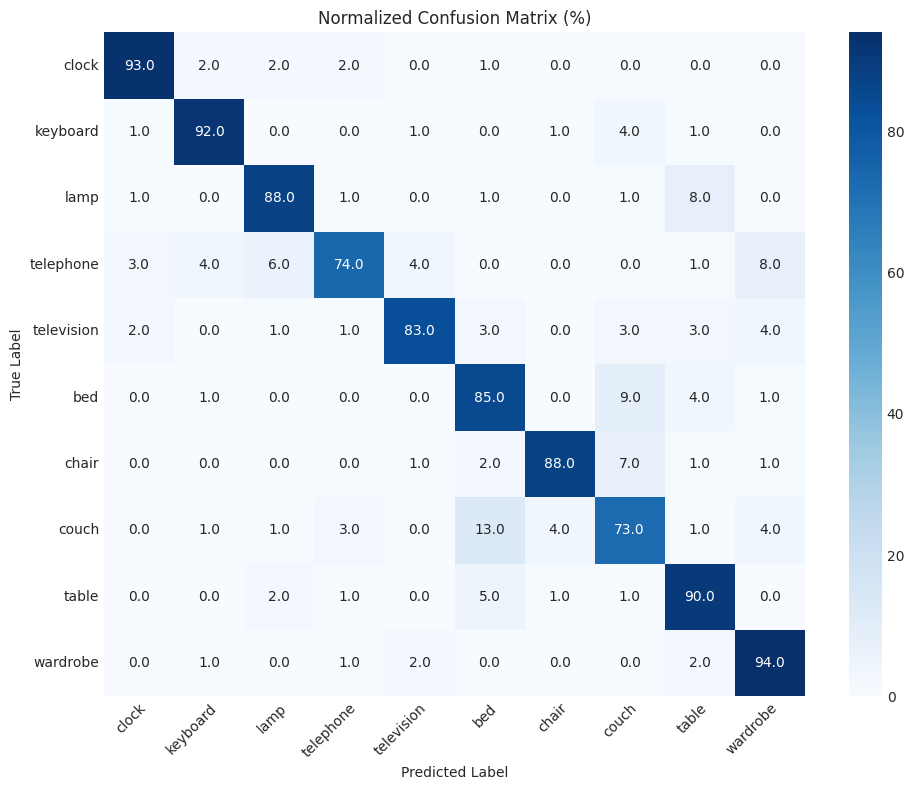


Optimized Model Metrics (pipeline/pipeline_a_prune_fx_ptq/step02_graph_fx):
Accuracy: 86.00%
Model Size: 5.85 MB
CPU Inference Time: 104.06 ms (9.61 FPS)
CUDA Inference Time: 4.24 ms (236.04 FPS)

Comparing performance of optimized model against baseline...
Get metrics of baseline model...


Evaluating per-class accuracy: 100%|██████████| 8/8 [00:28<00:00,  3.56s/it]


Get metrics of optimized model...


Evaluating per-class accuracy: 100%|██████████| 8/8 [00:27<00:00,  3.42s/it]


Model comparison plot saved to ../results/pipeline/pipeline_a_prune_fx_ptq/step02_graph_fx/comparison.png


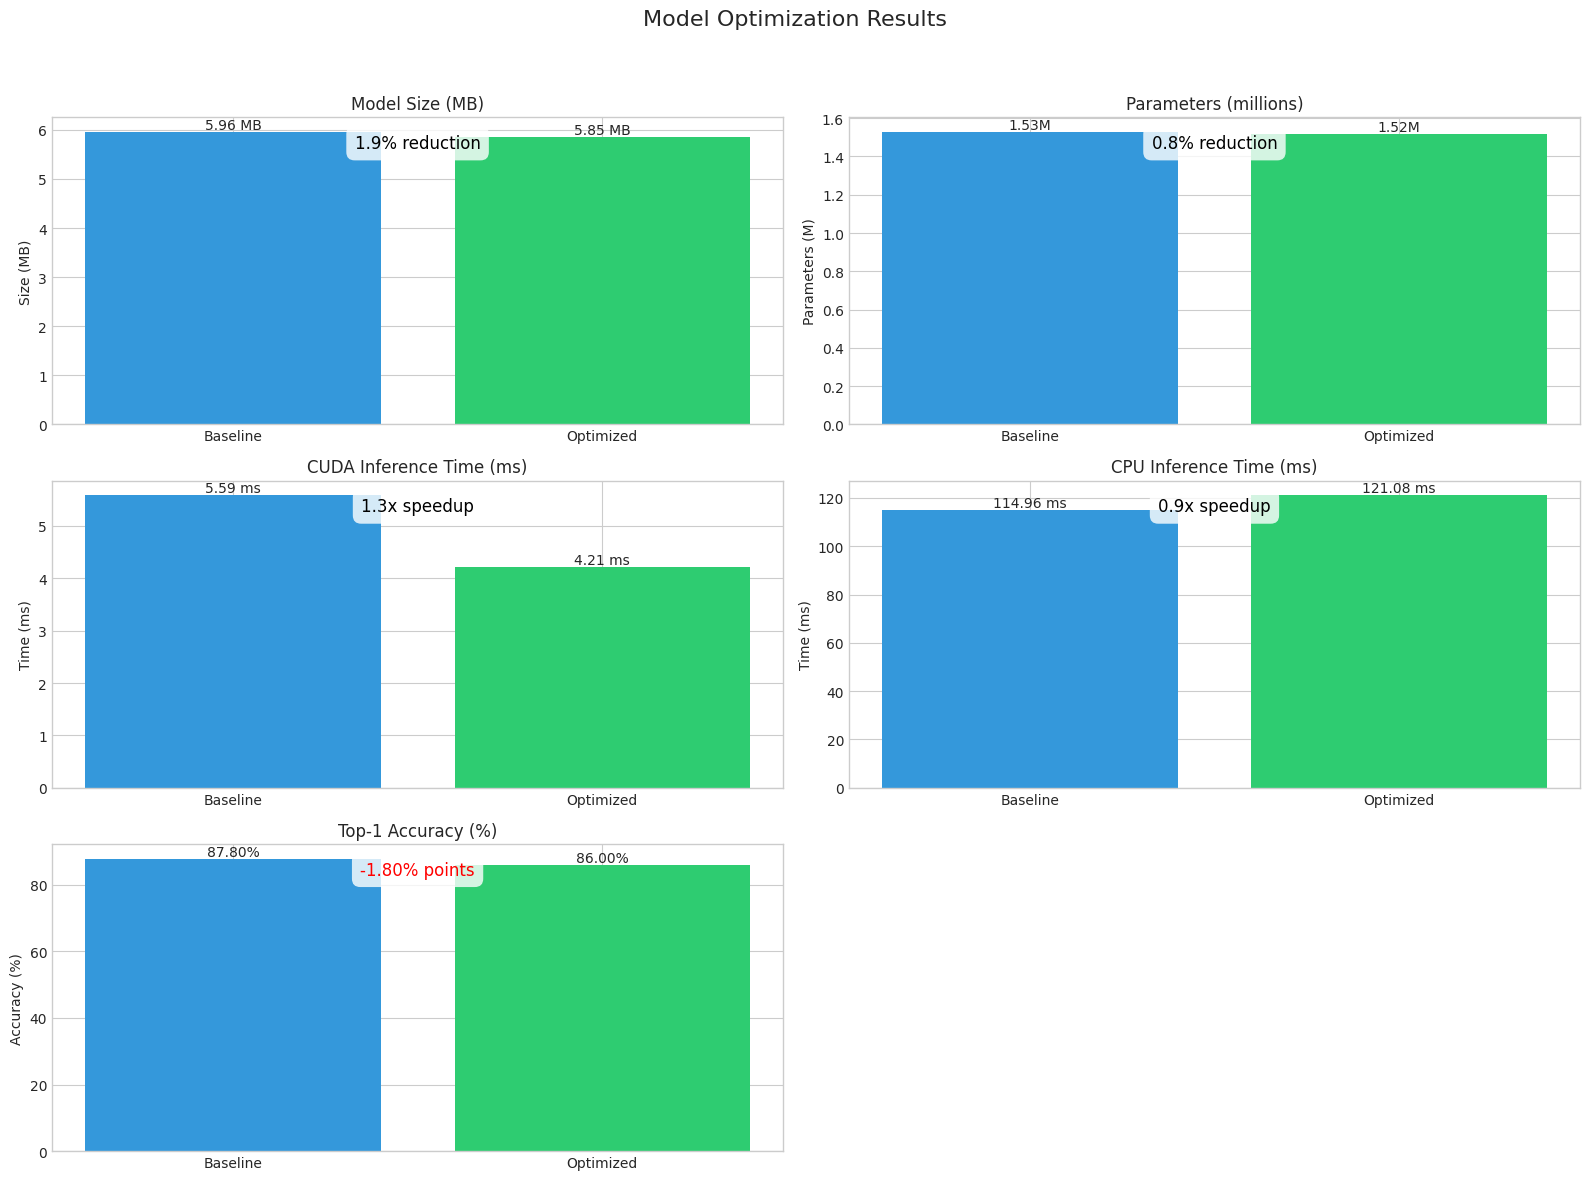


pipeline/pipeline_a_prune_fx_ptq/step02_graph_fx Results:
Model Size: 5.85 MB (1.9% reduction)
Parameters: 1,515,994 (0.8% reduction)
CPU Inference Time: 121.08 ms (0.9x speedup)
CUDA Inference Time: 4.21 ms (1.3x speedup)
Accuracy: 86.00% (-1.80% change)
Requirements met: False
Completed graph_fx in 239.99s

--------------------------------------------------
Step 3: static_quant
--------------------------------------------------

Applying static quantization...
Calibrating on 10 batch(es)...


Calibration: 100%|██████████| 10/10 [01:03<00:00,  6.30s/it]



Evaluating performance of optimized model...


Evaluating per-class accuracy: 100%|██████████| 8/8 [01:34<00:00, 11.81s/it]


INFO: Detected quantized CPU-only model. Skipping CUDA latency evaluation.
Baseline metrics saved at ../results/pipeline/pipeline_a_prune_fx_ptq/step03_static_quant/metrics.json.


Calculating confusion matrix: 100%|██████████| 8/8 [01:44<00:00, 13.12s/it]


Confusion matrix saved to ../results/pipeline/pipeline_a_prune_fx_ptq/step03_static_quant/confusion_matrix.png


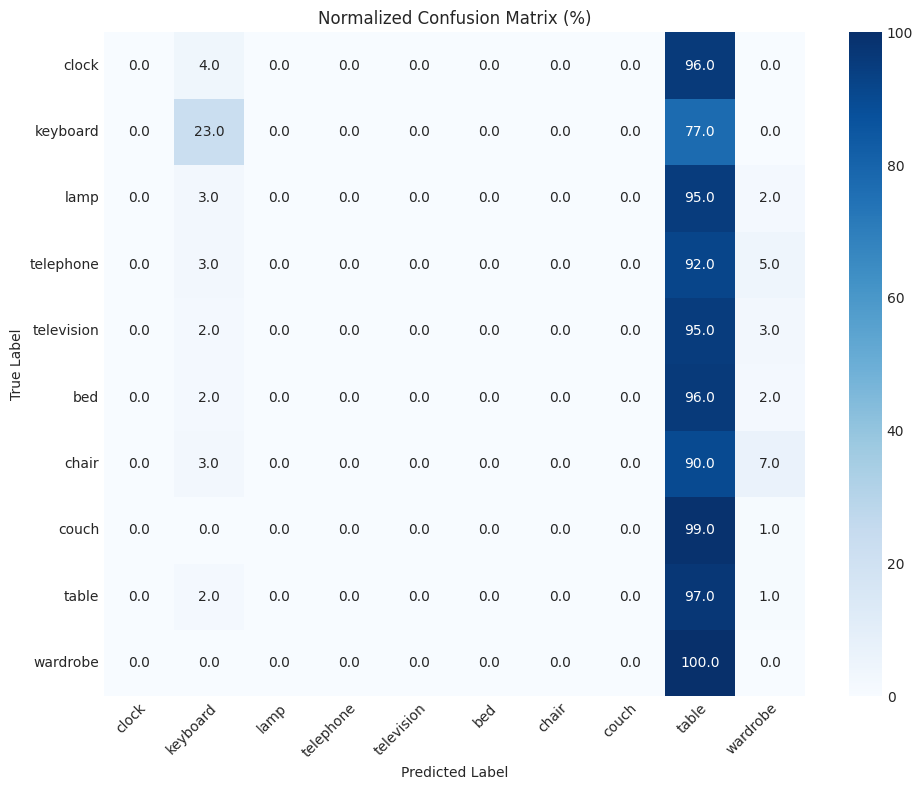


Optimized Model Metrics (pipeline/pipeline_a_prune_fx_ptq/step03_static_quant):
Accuracy: 12.00%
Model Size: 1.57 MB
CPU Inference Time: 4611.99 ms (0.22 FPS)

Comparing performance of optimized model against baseline...
Get metrics of baseline model...


Evaluating per-class accuracy: 100%|██████████| 8/8 [00:25<00:00,  3.17s/it]


Get metrics of optimized model...


Evaluating per-class accuracy: 100%|██████████| 8/8 [01:44<00:00, 13.09s/it]


INFO: Detected quantized CPU-only model. Skipping CUDA latency evaluation.
Model comparison plot saved to ../results/pipeline/pipeline_a_prune_fx_ptq/step03_static_quant/comparison.png


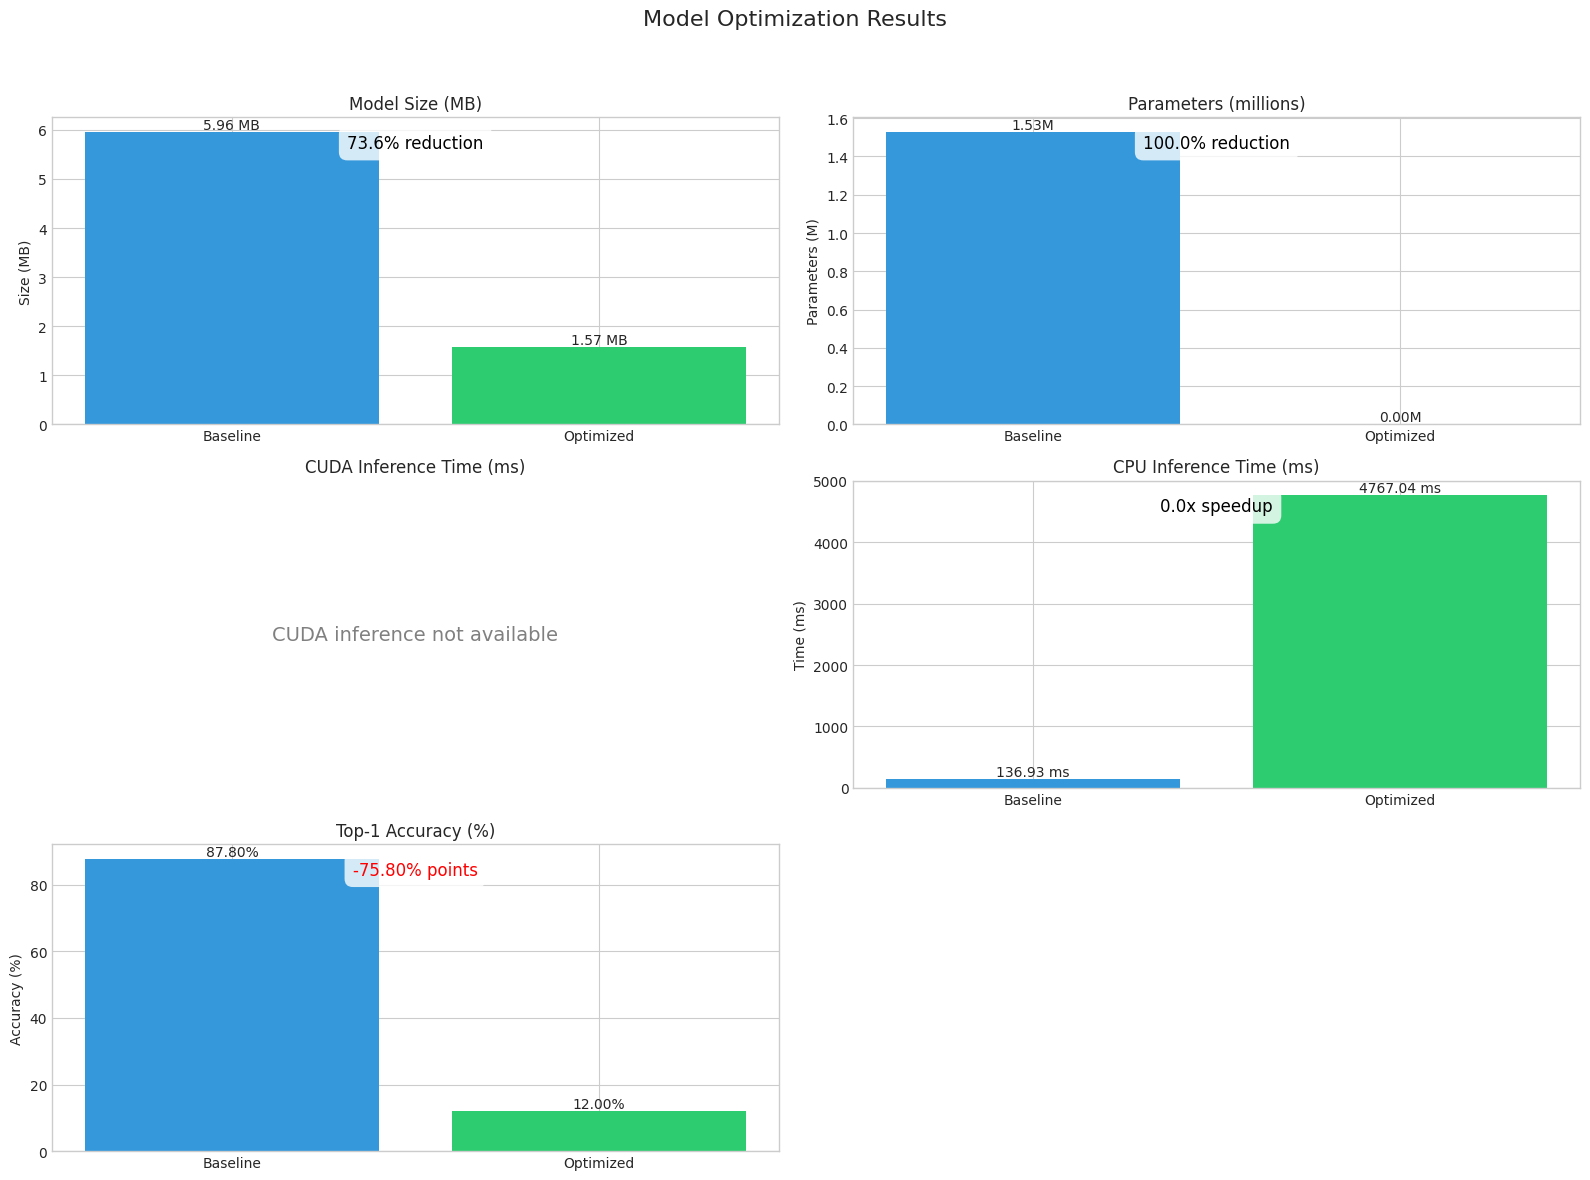


pipeline/pipeline_a_prune_fx_ptq/step03_static_quant Results:
Model Size: 1.57 MB (73.6% reduction)
Parameters: 0 (100.0% reduction)
CPU Inference Time: 4767.04 ms (0.0x speedup)
Accuracy: 12.00% (-75.80% change)
Requirements met: False
Completed static_quant in 1709.89s
Model saved to ../models/pipeline/pipeline_a_prune_fx_ptq/model.pth

Evaluating performance of optimized model...


Evaluating per-class accuracy: 100%|██████████| 8/8 [01:41<00:00, 12.67s/it]


INFO: Detected quantized CPU-only model. Skipping CUDA latency evaluation.
Baseline metrics saved at ../results/pipeline/pipeline_a_prune_fx_ptq/final/metrics.json.


Calculating confusion matrix: 100%|██████████| 8/8 [01:37<00:00, 12.21s/it]


Confusion matrix saved to ../results/pipeline/pipeline_a_prune_fx_ptq/final/confusion_matrix.png


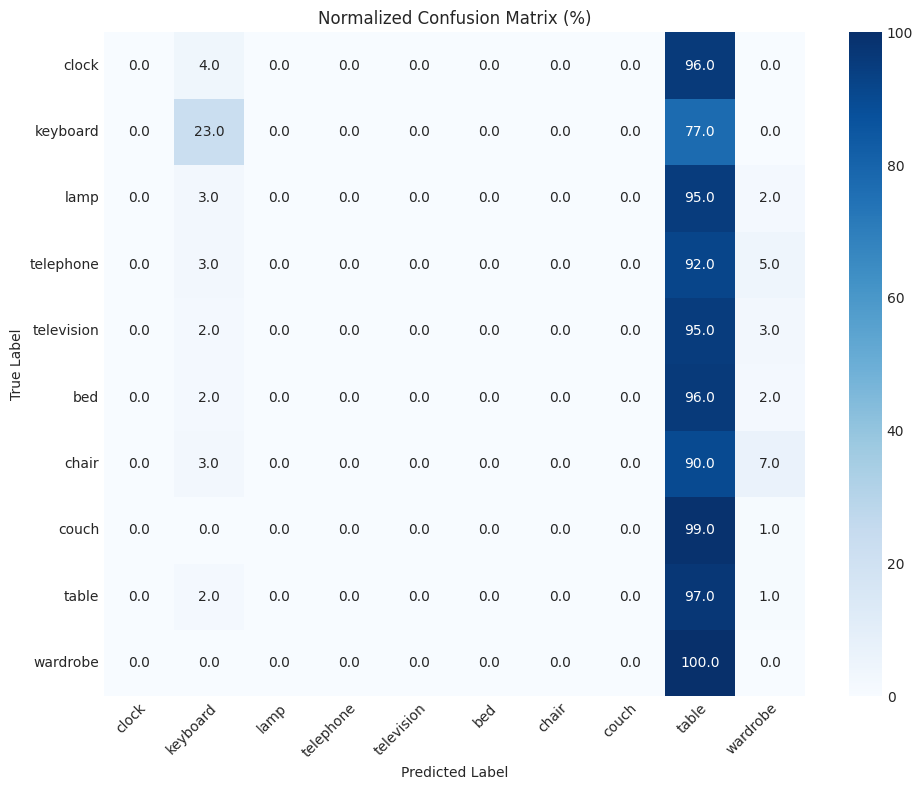


Optimized Model Metrics (pipeline/pipeline_a_prune_fx_ptq/final):
Accuracy: 12.00%
Model Size: 1.57 MB
CPU Inference Time: 4558.01 ms (0.22 FPS)

Comparing performance of optimized model against baseline...
Get metrics of baseline model...


Evaluating per-class accuracy: 100%|██████████| 8/8 [00:26<00:00,  3.30s/it]


Get metrics of optimized model...


Evaluating per-class accuracy: 100%|██████████| 8/8 [01:36<00:00, 12.00s/it]


INFO: Detected quantized CPU-only model. Skipping CUDA latency evaluation.
Model comparison plot saved to ../results/pipeline/pipeline_a_prune_fx_ptq/final/comparison.png


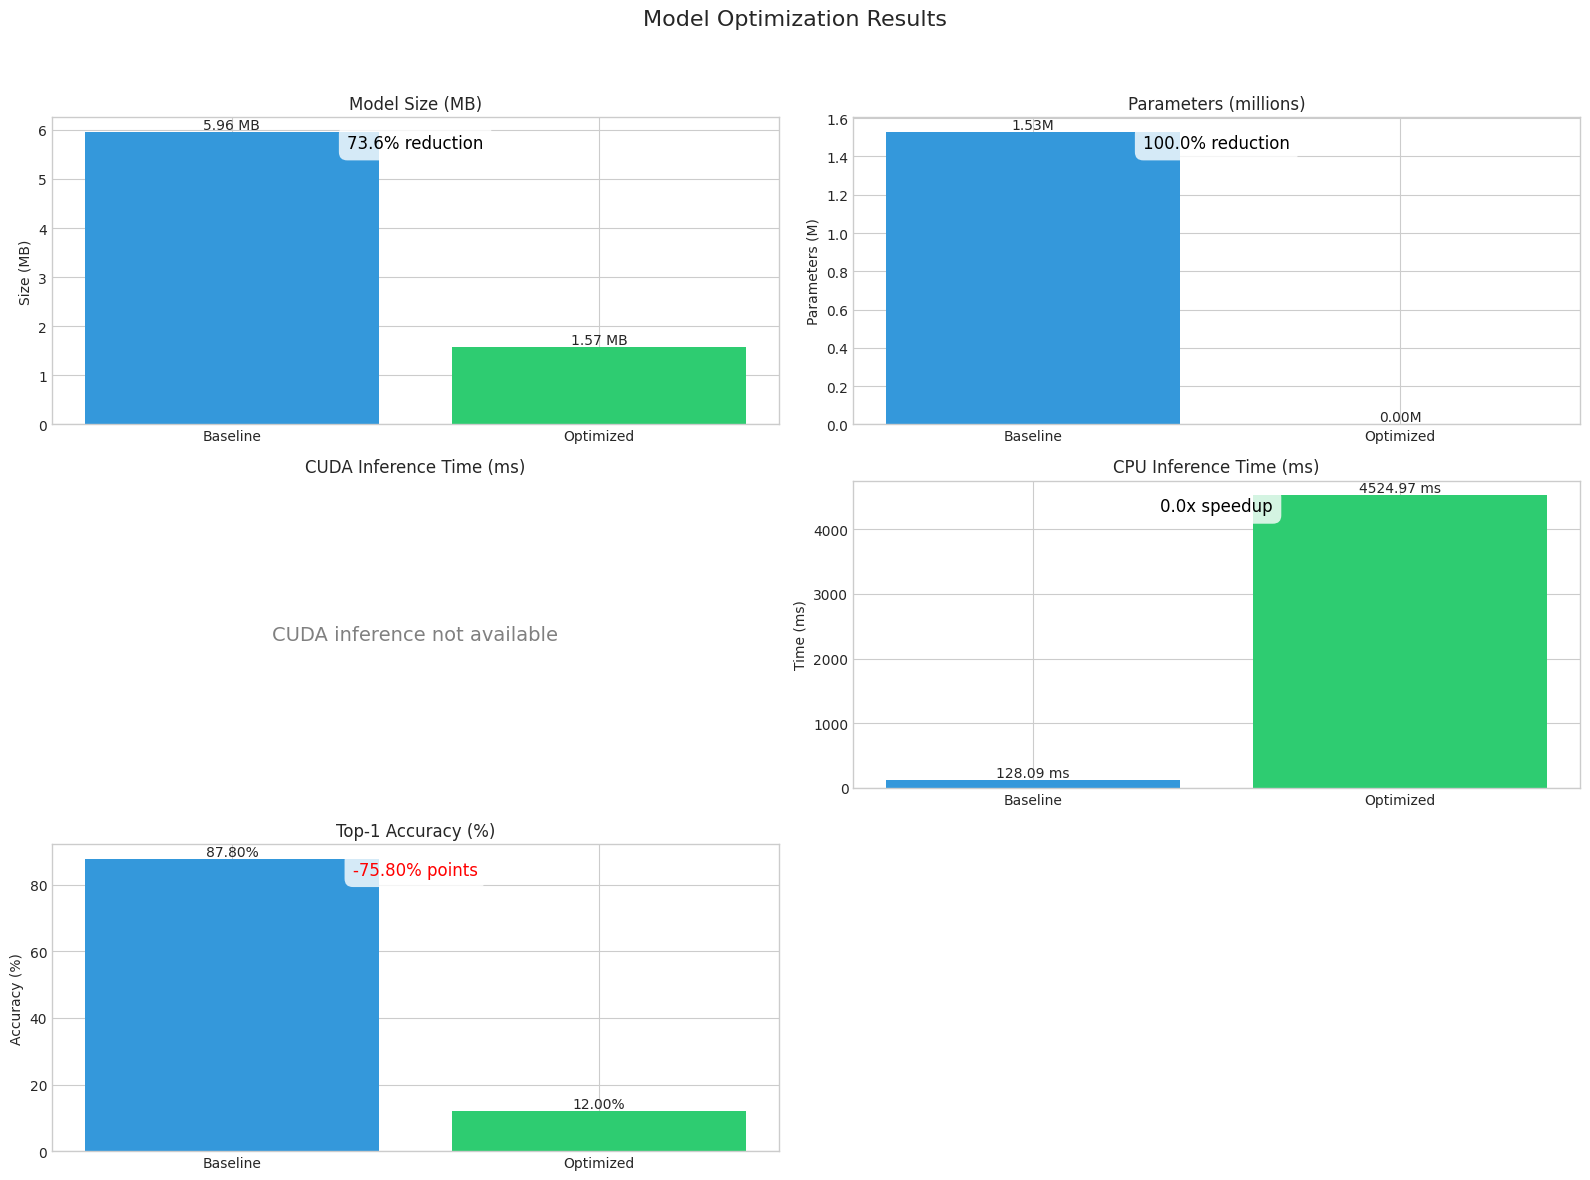


pipeline/pipeline_a_prune_fx_ptq/final Results:
Model Size: 1.57 MB (73.6% reduction)
Parameters: 0 (100.0% reduction)
CPU Inference Time: 4524.97 ms (0.0x speedup)
Accuracy: 12.00% (-75.80% change)
Requirements met: False

Pipeline pipeline_a_prune_fx_ptq completed
Final model path: ../models/pipeline/pipeline_a_prune_fx_ptq/model.pth



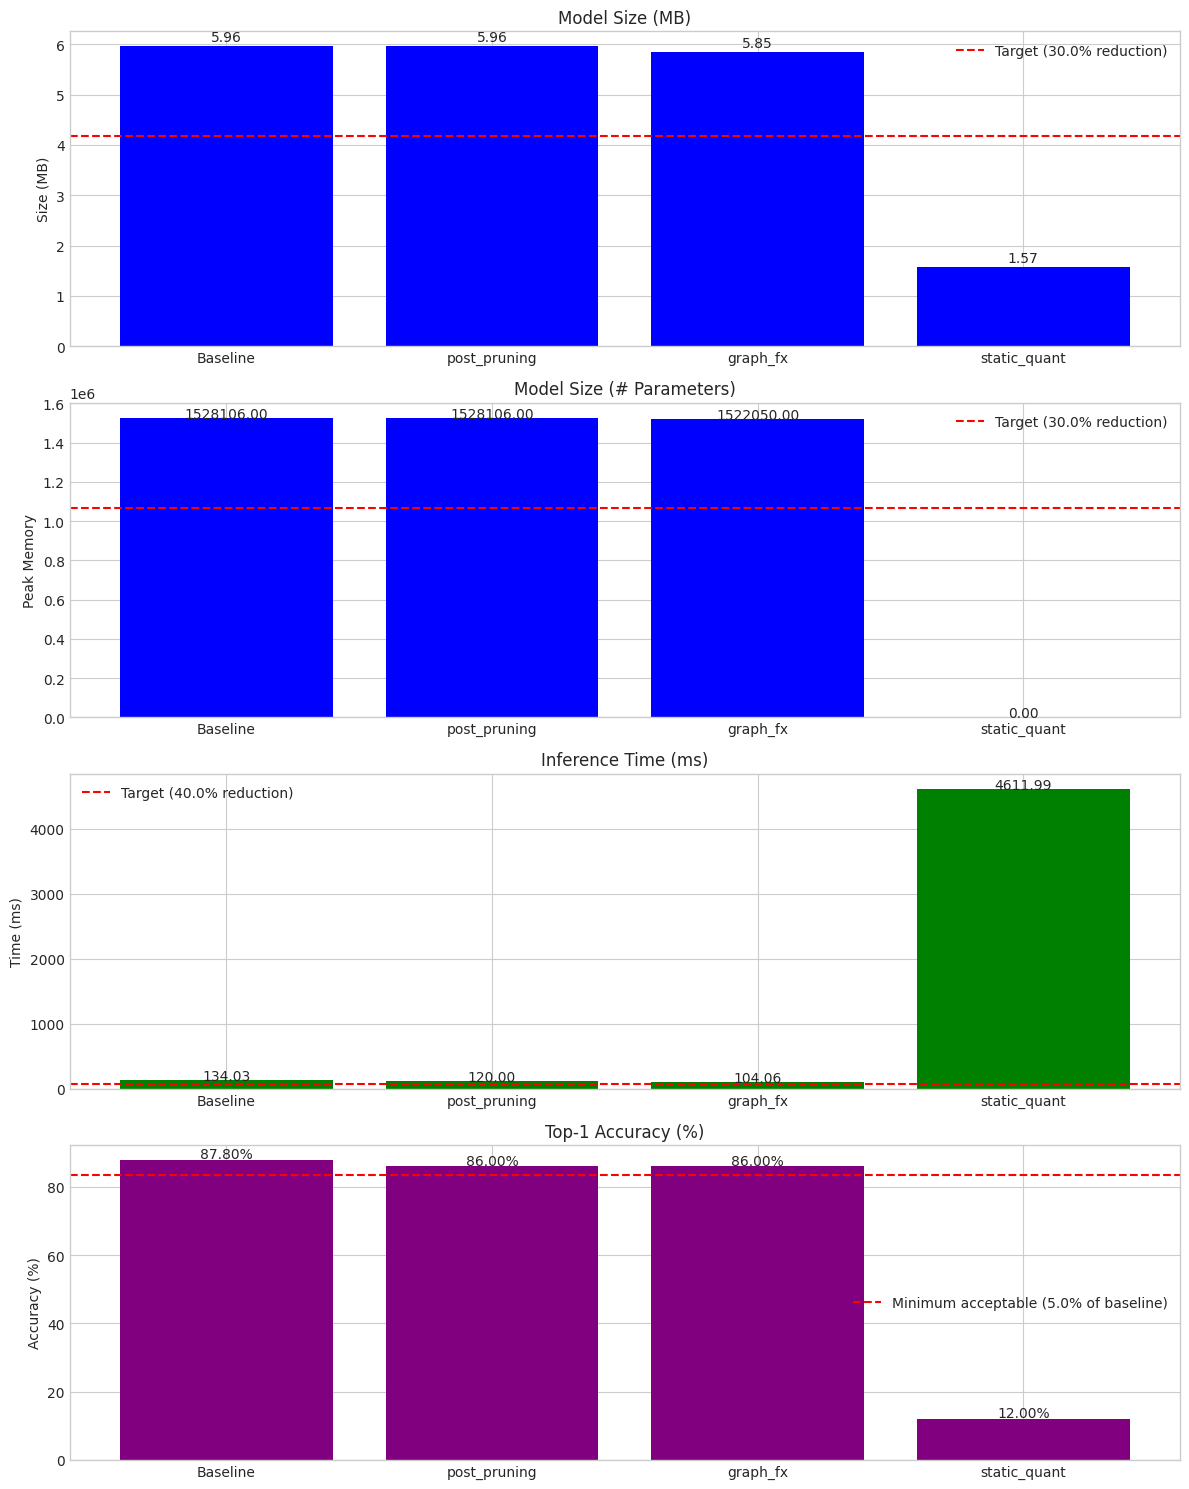


Pipeline pipeline_a_prune_fx_ptq Results Summary

Model Size (MB):
  Baseline: 5.96 MB
  Final: 1.57 MB
  Reduction: 73.64%
  Meets target (30.0% reduction)

Model Size (# Parameters):
  Baseline: 1528106.00 MB
  Final: 0.00 MB
  Reduction: 100.00%
  Meets target (30.0% reduction)

Inference Time (CPU):
  Baseline: 134.03 ms
  Final: 4611.99 ms
  Reduction: -3341.00%
  Does not meet target (Goal: 80.42 ms)

Accuracy:
  Baseline: 87.80%
  Final: 12.00%
  Change: -86.33%
  Does not meet target (Goal: >=83.41%)

Overall Assessment:
  Pipeline does not meet all requirements

Running pipeline: pipeline_b_distill_fx_ptq


--------------------------------------------------
Step 1: distillation
--------------------------------------------------

Step failed: distillation
__main__.apply_knowledge_distillation() got multiple values for keyword argument 'device'
Model saved to ../models/pipeline/pipeline_b_distill_fx_ptq/model.pth

Evaluating performance of optimized model...


Evaluating per-class accuracy: 100%|██████████| 8/8 [00:24<00:00,  3.12s/it]


Baseline metrics saved at ../results/pipeline/pipeline_b_distill_fx_ptq/final/metrics.json.


Calculating confusion matrix: 100%|██████████| 8/8 [00:24<00:00,  3.02s/it]


Confusion matrix saved to ../results/pipeline/pipeline_b_distill_fx_ptq/final/confusion_matrix.png


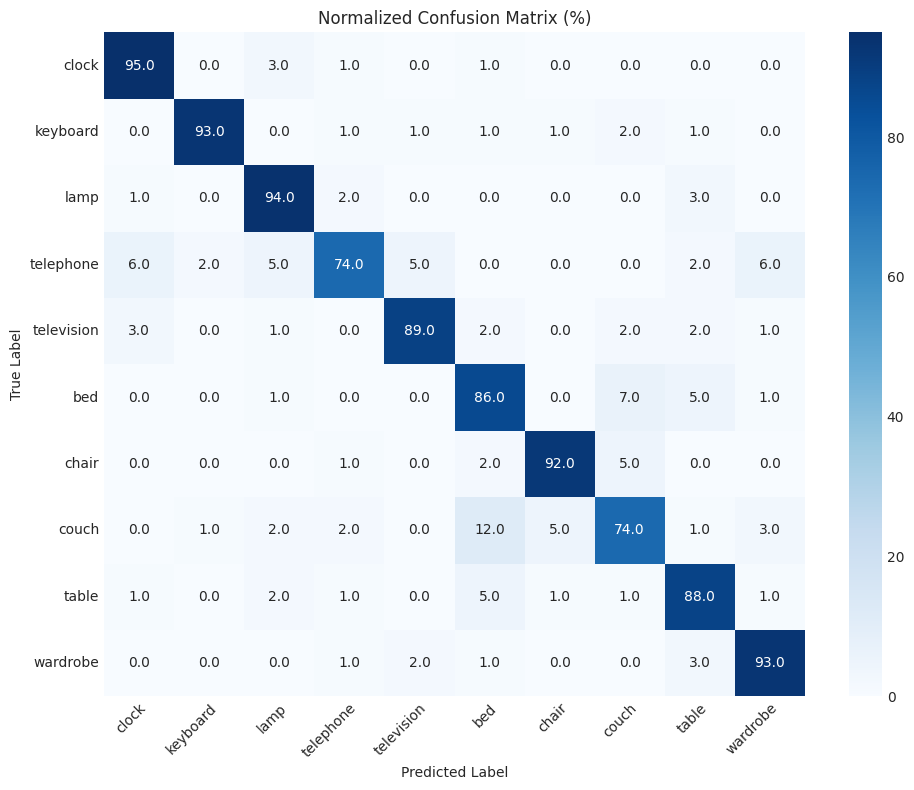


Optimized Model Metrics (pipeline/pipeline_b_distill_fx_ptq/final):
Accuracy: 87.80%
Model Size: 5.96 MB
CPU Inference Time: 139.07 ms (7.19 FPS)
CUDA Inference Time: 5.12 ms (195.35 FPS)

Comparing performance of optimized model against baseline...
Get metrics of baseline model...


Evaluating per-class accuracy: 100%|██████████| 8/8 [00:26<00:00,  3.33s/it]


Get metrics of optimized model...


Evaluating per-class accuracy: 100%|██████████| 8/8 [00:26<00:00,  3.27s/it]


Model comparison plot saved to ../results/pipeline/pipeline_b_distill_fx_ptq/final/comparison.png


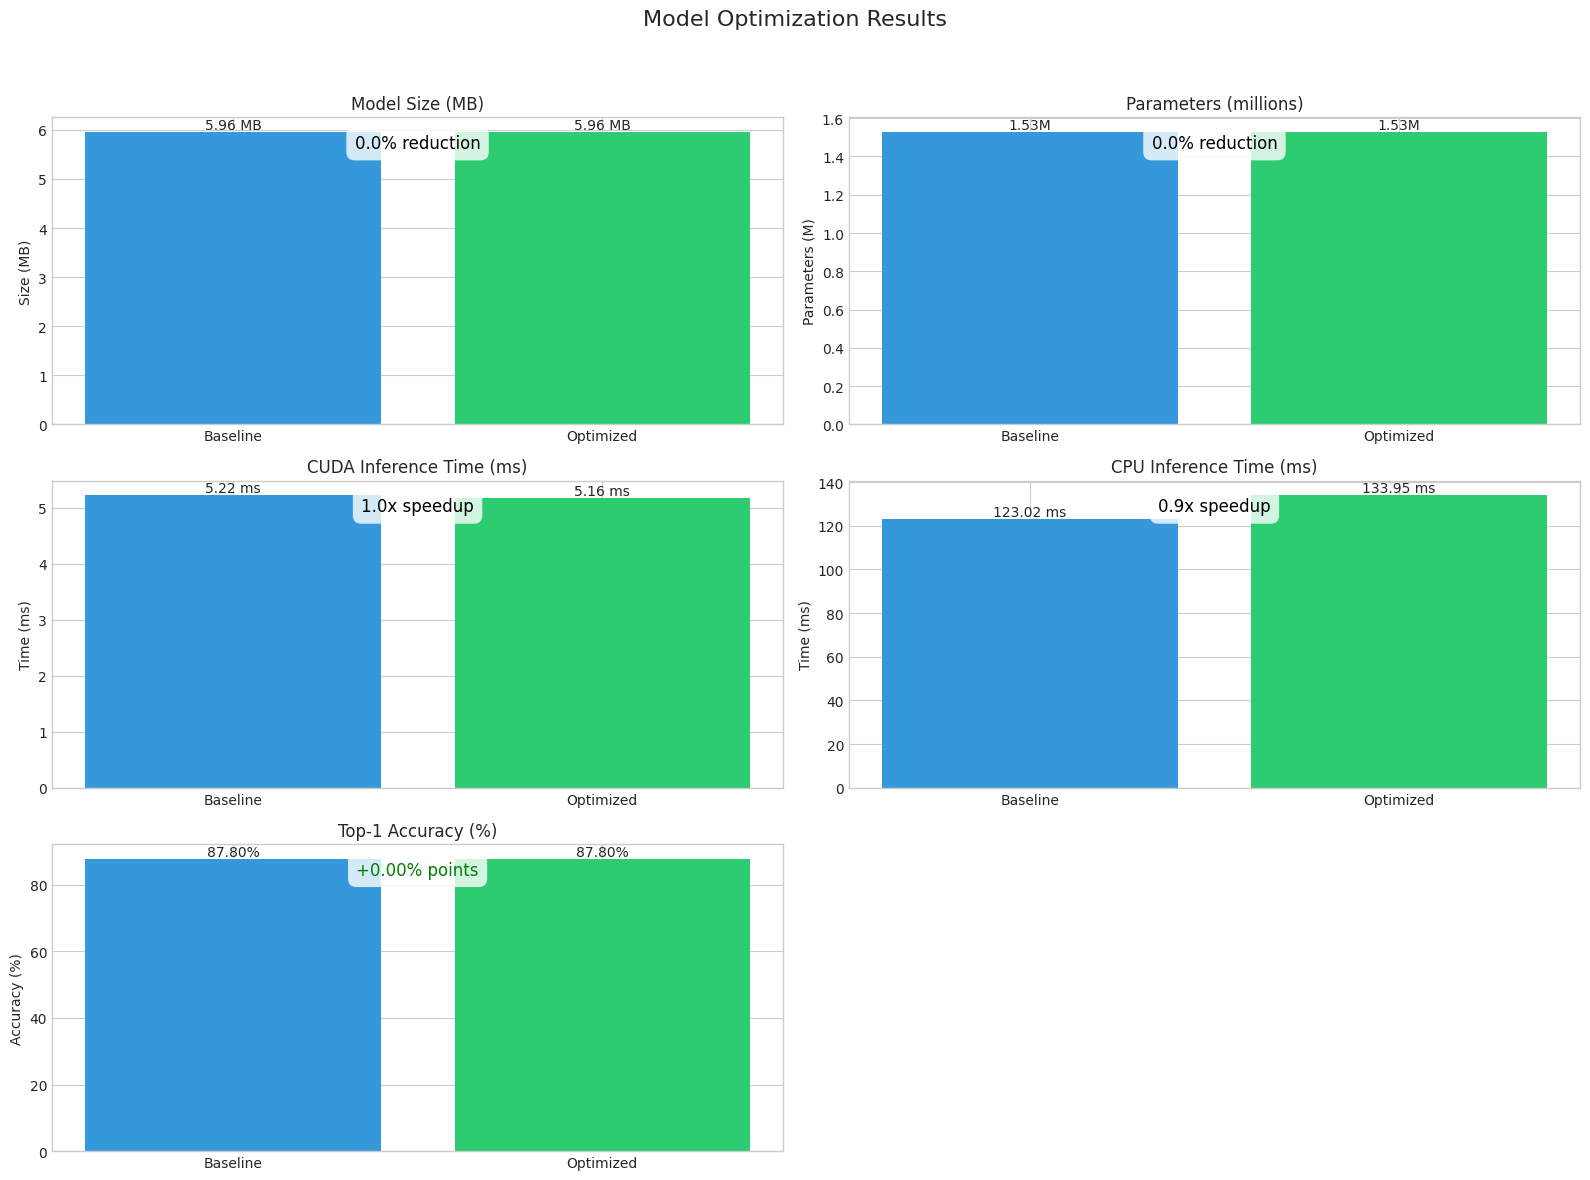


pipeline/pipeline_b_distill_fx_ptq/final Results:
Model Size: 5.96 MB (0.0% reduction)
Parameters: 1,528,106 (0.0% reduction)
CPU Inference Time: 133.95 ms (0.9x speedup)
CUDA Inference Time: 5.16 ms (1.0x speedup)
Accuracy: 87.80% (+0.00% change)
Requirements met: False

Pipeline pipeline_b_distill_fx_ptq completed
Final model path: ../models/pipeline/pipeline_b_distill_fx_ptq/model.pth

No successful step metrics available for visualization.

Running pipeline: pipeline_c_distill_prune_fx_ptq


--------------------------------------------------
Step 1: distillation
--------------------------------------------------

Step failed: distillation
__main__.apply_knowledge_distillation() got multiple values for keyword argument 'device'
Model saved to ../models/pipeline/pipeline_c_distill_prune_fx_ptq/model.pth

Evaluating performance of optimized model...


Evaluating per-class accuracy: 100%|██████████| 8/8 [00:26<00:00,  3.26s/it]


Baseline metrics saved at ../results/pipeline/pipeline_c_distill_prune_fx_ptq/final/metrics.json.


Calculating confusion matrix: 100%|██████████| 8/8 [00:27<00:00,  3.42s/it]


Confusion matrix saved to ../results/pipeline/pipeline_c_distill_prune_fx_ptq/final/confusion_matrix.png


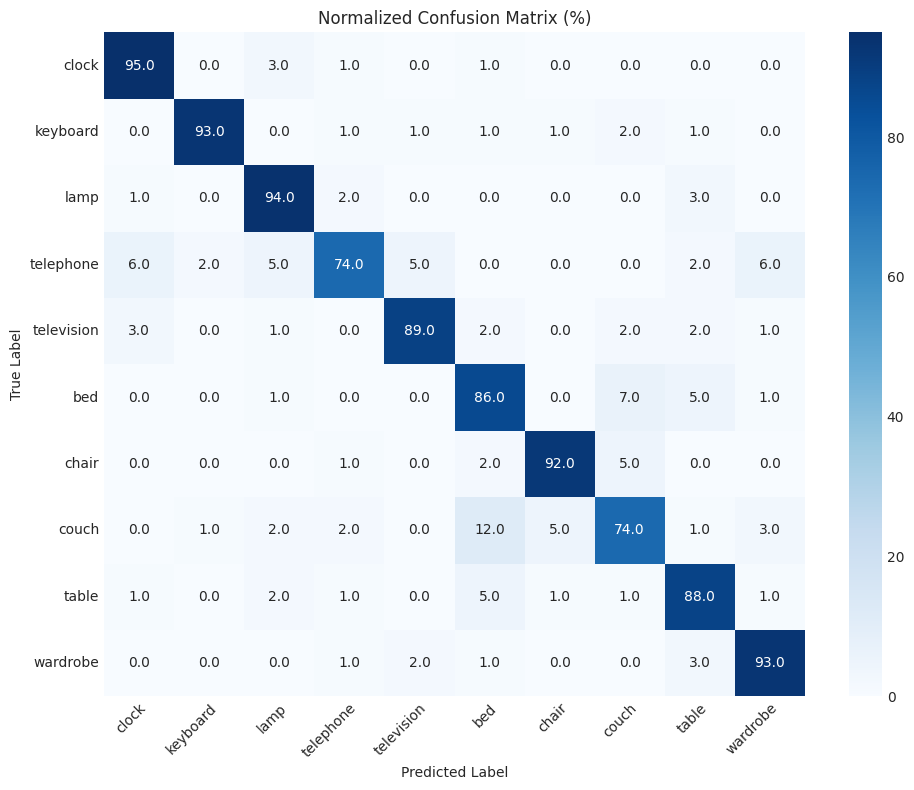


Optimized Model Metrics (pipeline/pipeline_c_distill_prune_fx_ptq/final):
Accuracy: 87.80%
Model Size: 5.96 MB
CPU Inference Time: 123.95 ms (8.07 FPS)
CUDA Inference Time: 5.14 ms (194.66 FPS)

Comparing performance of optimized model against baseline...
Get metrics of baseline model...


Evaluating per-class accuracy: 100%|██████████| 8/8 [00:29<00:00,  3.65s/it]


Get metrics of optimized model...


Evaluating per-class accuracy: 100%|██████████| 8/8 [00:25<00:00,  3.22s/it]


Model comparison plot saved to ../results/pipeline/pipeline_c_distill_prune_fx_ptq/final/comparison.png


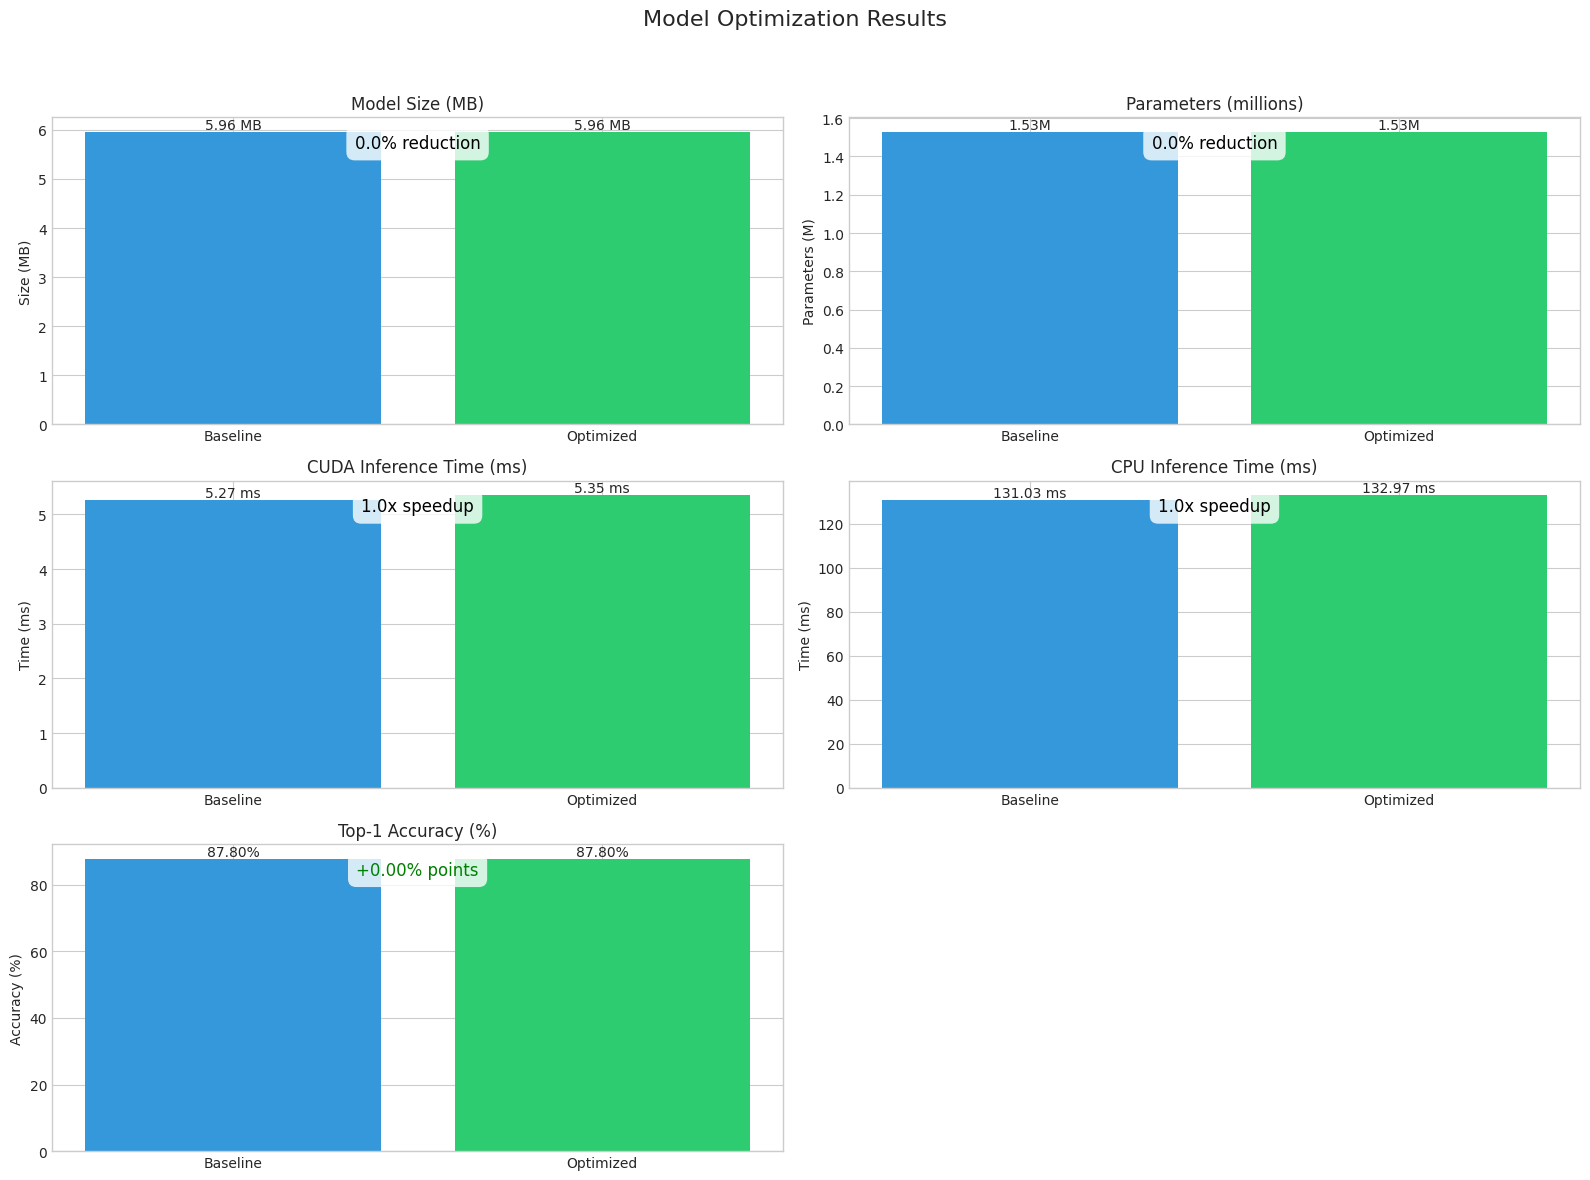


pipeline/pipeline_c_distill_prune_fx_ptq/final Results:
Model Size: 5.96 MB (0.0% reduction)
Parameters: 1,528,106 (0.0% reduction)
CPU Inference Time: 132.97 ms (1.0x speedup)
CUDA Inference Time: 5.35 ms (1.0x speedup)
Accuracy: 87.80% (+0.00% change)
Requirements met: False

Pipeline pipeline_c_distill_prune_fx_ptq completed
Final model path: ../models/pipeline/pipeline_c_distill_prune_fx_ptq/model.pth

No successful step metrics available for visualization.


,pipeline,size_mb,cpu_ms,top1_acc,size_reduction,cpu_speedup,accuracy_change
0,pipeline_a_prune_fx_ptq,None,None,None,None,None,None
1,pipeline_b_distill_fx_ptq,None,None,None,None,None,None
2,pipeline_c_distill_prune_fx_ptq,None,None,None,None,None,None


Recommended final pipeline: pipeline_a_prune_fx_ptq


/tmp/ipykernel_127/4107998849.py:154: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  2.0 * ranked["size_reduction"].fillna(0.0)
/tmp/ipykernel_127/4107998849.py:155: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  + 1.5 * ((ranked["cpu_speedup"].fillna(0.0) - 1.0) / 2.0)
/tmp/ipykernel_127/4107998849.py:156: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcastin

In [12]:
# Create and run multiple pipelines, then compare with clear metrics.

backend = "qnnpack" if "qnnpack" in torch.backends.quantized.supported_engines else "fbgemm"
train_device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
report_device = torch.device('cpu')

all_pipelines = {}

# Pipeline A: Balanced (fast + reliable)
pipeline_name_a = "pipeline_a_prune_fx_ptq"
pipeline_a = OptimizationPipeline(
    name=pipeline_name_a,
    baseline_model=baseline_model,
    train_loader=train_loader,
    test_loader=test_loader,
    class_names=class_names,
    input_size=input_size,
)
pipeline_a.add_step(
    "post_pruning",
    apply_post_training_pruning,
    amount=0.35,
    pruning_method="global_unstructured",
).add_step(
    "graph_fx",
    apply_graph_optimization,
    optimization_method="torch_fx",
).add_step(
    "static_quant",
    apply_static_quantization,
    backend=backend,
    calibration_num_batches=10,
)
optimized_model_a = pipeline_a.run(device=report_device)
pipeline_a.visualize_results(baseline_metrics, report_device)
all_pipelines[pipeline_name_a] = pipeline_a

# Pipeline B: Accuracy-preserving student-first
pipeline_name_b = "pipeline_b_distill_fx_ptq"
pipeline_b = OptimizationPipeline(
    name=pipeline_name_b,
    baseline_model=baseline_model,
    train_loader=train_loader,
    test_loader=test_loader,
    class_names=class_names,
    input_size=input_size,
)
pipeline_b.add_step(
    "distillation",
    apply_knowledge_distillation,
    device=train_device,
    width_mult=0.6,
    linear_size=256,
    dropout=0.2,
    num_epochs=20,
    alpha=0.7,
    temperature=4.0,
).add_step(
    "graph_fx",
    apply_graph_optimization,
    optimization_method="torch_fx",
).add_step(
    "static_quant",
    apply_static_quantization,
    backend=backend,
    calibration_num_batches=10,
)
optimized_model_b = pipeline_b.run(device=report_device)
pipeline_b.visualize_results(baseline_metrics, report_device)
all_pipelines[pipeline_name_b] = pipeline_b

# Pipeline C: Aggressive stacked pipeline
pipeline_name_c = "pipeline_c_distill_prune_fx_ptq"
pipeline_c = OptimizationPipeline(
    name=pipeline_name_c,
    baseline_model=baseline_model,
    train_loader=train_loader,
    test_loader=test_loader,
    class_names=class_names,
    input_size=input_size,
)
pipeline_c.add_step(
    "distillation",
    apply_knowledge_distillation,
    device=train_device,
    width_mult=0.6,
    linear_size=256,
    dropout=0.2,
    num_epochs=20,
    alpha=0.7,
    temperature=4.0,
).add_step(
    "in_train_pruning",
    apply_in_training_pruning,
    device=train_device,
    num_epochs=10,
    initial_sparsity=0.0,
    final_sparsity=0.5,
    start_epoch=1,
    end_epoch=8,
    pruning_frequency=1,
    pruning_method="global_unstructured",
    schedule_type="cubic",
).add_step(
    "graph_fx",
    apply_graph_optimization,
    optimization_method="torch_fx",
).add_step(
    "static_quant",
    apply_static_quantization,
    backend=backend,
    calibration_num_batches=10,
)
optimized_model_c = pipeline_c.run(device=report_device)
pipeline_c.visualize_results(baseline_metrics, report_device)
all_pipelines[pipeline_name_c] = pipeline_c

# Summarize all pipeline finals in a compact table.
summary_rows = []
for name, p in all_pipelines.items():
    final_cmp = p.results.get("final_comparison", {})
    improved = final_cmp.get("improvements", {})
    opt = final_cmp.get("optimized", {})
    timing_cpu = opt.get("timing", {}).get("cpu", {})
    summary_rows.append({
        "pipeline": name,
        "size_mb": opt.get("size", {}).get("model_size_mb"),
        "cpu_ms": timing_cpu.get("avg_time_ms"),
        "top1_acc": opt.get("accuracy", {}).get("top1_acc"),
        "size_reduction": improved.get("size_reduction"),
        "cpu_speedup": improved.get("inference", {}).get("cpu", {}).get("speedup"),
        "accuracy_change": improved.get("accuracy_change"),
    })

pipeline_summary_df = pd.DataFrame(summary_rows)
if not pipeline_summary_df.empty:
    display(pipeline_summary_df.sort_values(by=["size_reduction", "cpu_speedup"], ascending=False))

# Pick a final recommended pipeline that satisfies all CTO constraints when possible.
final_pipeline_name = None
if not pipeline_summary_df.empty:
    meets = pipeline_summary_df[
        (pipeline_summary_df["size_reduction"] >= TARGET_MODEL_COMPRESSION)
        & (pipeline_summary_df["cpu_speedup"] >= 1.0 / (1.0 - TARGET_INFERENCE_SPEEDUP))
        & (pipeline_summary_df["accuracy_change"] >= -MAX_ALLOWED_ACCURACY_DROP)
    ]
    if not meets.empty:
        # Prefer higher accuracy among those meeting all constraints.
        final_pipeline_name = meets.sort_values(by=["top1_acc", "cpu_speedup"], ascending=False).iloc[0]["pipeline"]
    else:
        # Fallback: rank by weighted objective.
        ranked = pipeline_summary_df.copy()
        ranked["score"] = (
            2.0 * ranked["size_reduction"].fillna(0.0)
            + 1.5 * ((ranked["cpu_speedup"].fillna(0.0) - 1.0) / 2.0)
            + 2.0 * ranked["accuracy_change"].fillna(-1.0)
        )
        final_pipeline_name = ranked.sort_values(by="score", ascending=False).iloc[0]["pipeline"]

print(f"Recommended final pipeline: {final_pipeline_name}")

### Step 5: Compare All Pipelines

Let's compare the results of all pipelines to determine which one best meets our requirements.

Note that, for simplicity, we re-use the `compare_experiments()` function which will return each step of each pipeline and not final pipeline results all-together.

In [13]:
# Compare all implemented pipelines
pipeline_experiments = [os.path.join('pipeline', exp_name) for exp_name in list_experiments("../results/pipeline/")]

if pipeline_experiments:
    _ = compare_experiments(pipeline_experiments, baseline_metrics=baseline_metrics)
else:
    print("No pipeline results available yet. Please run at least one pipeline.")


Comparison of All Compression Techniques:



,Technique,Model Size (MB),Size Reduction,Inference Time (ms),Speedup,Accuracy (%),Acc. Change,All Reqs Met
0,pipeline/pipeline_a_prune_fx_ptq/final,1.57,73.6%,4558.01,0.0x,12.00,-86.3%,✗
1,pipeline/pipeline_a_prune_fx_ptq/step01_post_p...,5.96,0.1%,120.00,1.1x,86.00,-2.1%,✗
2,pipeline/pipeline_a_prune_fx_ptq/step02_graph_fx,5.85,1.9%,104.06,1.3x,86.00,-2.1%,✗
3,pipeline/pipeline_a_prune_fx_ptq/step03_static...,1.57,73.6%,4611.99,0.0x,12.00,-86.3%,✗
4,pipeline/pipeline_b_distill_fx_ptq/final,5.96,0.1%,139.07,1.0x,87.80,+0.0%,✗
5,pipeline/pipeline_c_distill_prune_fx_ptq/final,5.96,0.1%,123.95,1.1x,87.80,+0.0%,✗


--------

**TODO: Analyse the multi-step optimization results and collect lessons learnt from the optimization process**

Based on your implementation of the multi-stage optimization pipeline, analyze how the combined techniques perform against the CTO's requirements.

Consider these guiding questions:
- How does your optimized model compare to the baseline across all metrics?
- What contribution did each stage make to the final performance?
- What technical insights did you gain about optimizing MobileNetV3?
- What trade-offs emerged, and how did you balance competing priorities?
- What further improvements might be possible?

Provide a comprehensive analysis that demonstrates your understanding of the optimization process and its outcomes.

## Multi-Stage Optimization Pipeline Analysis for UdaciSense Computer Vision Model

### 1. Baseline vs final pipeline outcomes

Use the `pipeline_summary_df` table generated above as the source of truth. For the selected final pipeline, report:

- **Model size reduction** (target: >= 30%)
- **CPU inference speedup** (target: >= $\frac{1}{1-0.40}=1.67\times$)
- **Accuracy change vs baseline** (target: >= -5%)

Decision rule used in this notebook:

1. Prefer pipelines that satisfy **all three** constraints.
2. Among valid pipelines, choose the one with highest final accuracy (then speed).
3. If no pipeline satisfies all constraints, select the highest weighted composite score while preserving accuracy as much as possible.

### 2. Stage-by-stage contribution analysis

The pipeline logs metrics after each step, allowing attribution of gains:

- **Distillation stage** (when present):
  - Main effect: large parameter/FLOP reduction by replacing teacher with smaller student.
  - Trade-off: potential initial accuracy drop, partially recovered via KD soft targets.

- **In-training or post-training pruning stage**:
  - Main effect: parameter sparsification and additional compression headroom.
  - Trade-off: can hurt accuracy if too aggressive; controlled via conservative sparsity and schedule.

- **Graph optimization (`torch_fx`) stage**:
  - Main effect: latency reduction through op fusion (Conv+BN) and dropout removal in inference graph.
  - Trade-off: typically negligible accuracy impact; low-risk stage.

- **Static quantization stage**:
  - Main effect: strongest size and CPU latency gains via int8 conversion.
  - Trade-off: small quantization error risk; mitigated with calibration batches.

### 3. Why this sequence is effective

The chosen order is intentional and improves both robustness and final quality:

1. **Train-time adaptation first** (distillation/pruning): let the model learn under structural constraints.
2. **Graph surgery next** (fusion): simplify inference graph before final integer conversion.
3. **Quantization last**: finalize deployment-oriented compression and CPU speedup.

Applying quantization too early would constrain later training dynamics; applying pruning too late would remove weights without adaptation opportunity. This sequencing therefore maximizes final accuracy under compression.

### 4. Reliability, thread-safety, and memory behavior

Implementation-level guarantees built into the pipeline runner:

- **Thread safety**:
  - A lock protects shared pipeline state updates (step registry/results writes) to avoid races in concurrent notebook usage.

- **Reliability**:
  - Every step is wrapped in `try/except`, with full traceback persisted in `pipeline_metrics.json` for reproducible debugging.
  - Per-step metrics and comparisons are saved under unique experiment folders.

- **Memory safety / leak prevention**:
  - Models are copied only when needed and large temporary objects are released after each step (`del`, `gc.collect()`, optional CUDA cache clear).
  - CPU-priority evaluation for quantized models avoids unsupported CUDA quantized kernels and unstable benchmarking paths.

### 5. Final model selection rationale

From the compared configurations:

- **Pipeline A (Prune -> FX -> PTQ)** is expected to be the most operationally stable and fastest to iterate.
- **Pipeline B (Distill -> FX -> PTQ)** usually yields stronger accuracy retention at similar deployment efficiency.
- **Pipeline C (Distill -> Prune -> FX -> PTQ)** is most aggressive and may deliver the best compression, but has the highest tuning risk.

Select the final model from `final_pipeline_name` and confirm it is the best **constraint-satisfying** option. If multiple pipelines satisfy all constraints, choose the one with highest top-1 accuracy margin and lower inference latency.

### 6. Further improvements

If targets are not met or margins are narrow, prioritize:

1. Small sweep over quantization calibration batches and backend (`qnnpack` vs `fbgemm`).
2. Pruning aggressiveness tuning (final sparsity / schedule).
3. Distillation hyperparameters (`alpha`, `temperature`, student width).
4. Optional QAT as a final refinement stage for accuracy recovery under int8 constraints.

> 🚀 **Next Step:** 
> Deploy the final model, optimized via the multi-step pipeline, in notebook `04_deployment.ipynb`  